In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium
import osmnx as ox

import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
### but :
### tenter de prédire les émissions de CO2 et la consommation totale d’énergie de bâtiments 
### non destinés à l’habitation pour lesquels elles n’ont pas encore été mesurées.

In [4]:
## source : contains KPI description
## https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

# Extract & Load

In [5]:
ls -lh ./data

total 1,4M
-rw-r--r-- 1 mijka mijka 1,2M  7 nov.  09:53 2016_Building_Energy_Benchmarking.csv
-rw-r--r-- 1 mijka mijka 143K  7 nov.  12:15 clean_seattle_buildings.csv


In [6]:
path = './data/'
csv_path = path + '2016_Building_Energy_Benchmarking.csv'
df = pd.read_csv(csv_path, on_bad_lines='skip', low_memory=False)

# Explore


## Functions

In [7]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [8]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [9]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

## Cardinality

In [10]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [11]:
df.shape

(3376, 46)

In [12]:
df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [13]:
df.dtypes

OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA          float64
SecondLarge

In [14]:
df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


In [15]:
df.isna().sum() 

OSEBuildingID                         0
DataYear                              0
BuildingType                          0
PrimaryPropertyType                   0
PropertyName                          0
Address                               0
City                                  0
State                                 0
ZipCode                              16
TaxParcelIdentificationNumber         0
CouncilDistrictCode                   0
Neighborhood                          0
Latitude                              0
Longitude                             0
YearBuilt                             0
NumberofBuildings                     8
NumberofFloors                        0
PropertyGFATotal                      0
PropertyGFAParking                    0
PropertyGFABuilding(s)                0
ListOfAllPropertyUseTypes             9
LargestPropertyUseType               20
LargestPropertyUseTypeGFA            20
SecondLargestPropertyUseType       1697
SecondLargestPropertyUseTypeGFA    1697


In [16]:
df.isnull().sum().sum()/len(df)

5.909952606635071

                                                         columns  count  \
Comments                                                Comments   3376   
Outlier                                                  Outlier   3344   
YearsENERGYSTARCertified                YearsENERGYSTARCertified   3257   
ThirdLargestPropertyUseType          ThirdLargestPropertyUseType   2780   
ThirdLargestPropertyUseTypeGFA    ThirdLargestPropertyUseTypeGFA   2780   
SecondLargestPropertyUseType        SecondLargestPropertyUseType   1697   
SecondLargestPropertyUseTypeGFA  SecondLargestPropertyUseTypeGFA   1697   
ENERGYSTARScore                                  ENERGYSTARScore    843   
LargestPropertyUseTypeGFA              LargestPropertyUseTypeGFA     20   
LargestPropertyUseType                    LargestPropertyUseType     20   
ZipCode                                                  ZipCode     16   
ListOfAllPropertyUseTypes              ListOfAllPropertyUseTypes      9   
SourceEUIWN(kBtu/sf)     

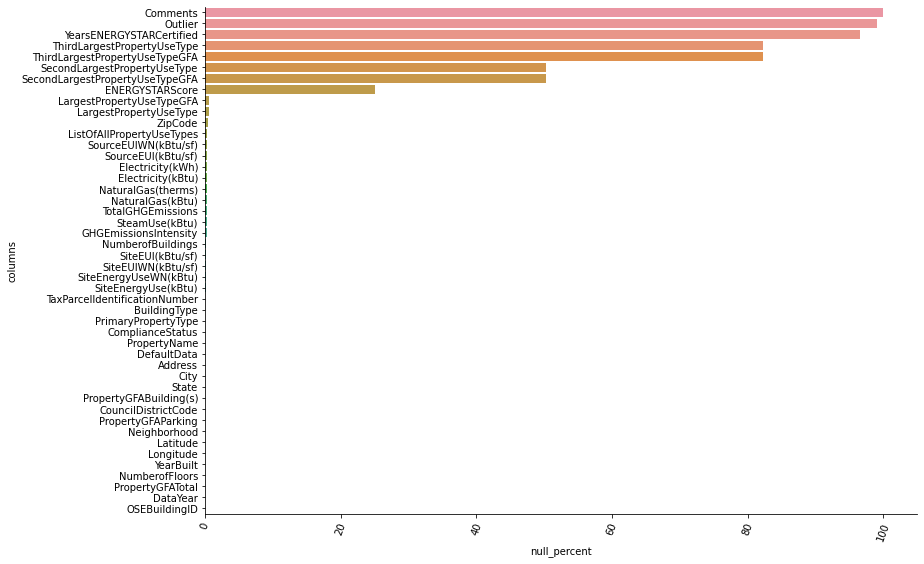

In [17]:
show_nulls(df)

## Duplicates

In [18]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3371    False
3372    False
3373    False
3374    False
3375    False
Length: 3376, dtype: bool

In [19]:
len(df)-len(df.drop_duplicates())

0

In [20]:
df.groupby(df.columns.tolist(),as_index=False).size()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,size


In [21]:
##df.groupby(['Longitude', 'Latitude'])['Crime type'].value_counts().to_frame('count')

## categories

In [22]:
df.select_dtypes(['category','object']).nunique()

BuildingType                        8
PrimaryPropertyType                24
PropertyName                     3362
Address                          3354
City                                1
State                               1
TaxParcelIdentificationNumber    3268
Neighborhood                       19
ListOfAllPropertyUseTypes         466
LargestPropertyUseType             56
SecondLargestPropertyUseType       50
ThirdLargestPropertyUseType        44
YearsENERGYSTARCertified           65
ComplianceStatus                    4
Outlier                             2
dtype: int64

In [23]:
df['ZipCode'].unique()

array([98101., 98121., 98104., 98154., 98118., 98105., 98112., 98125.,
       98109., 98070., 98108., 98199., 98115., 98107., 98144., 98103.,
       98119., 98136., 98122., 98126., 98133., 98146., 98033., 98106.,
       98111., 98134., 98117., 98116., 98191., 98164., 98195., 98185.,
       98181., 98102., 98168., 98155., 98006., 98124., 98053., 98012.,
       98013., 98028., 98178., 98114., 98127., 98165., 98011., 98198.,
       98113., 98040., 98204., 98177., 98020., 98272., 98145.,    nan])

In [24]:
df['Comments'].unique()

array([nan])

In [25]:
df['Comments'].nunique()

0

In [26]:
for column in df.columns:
    if df[column].nunique()<20:
        print('Colonne {}, valeurs uniques :\n{}\n'.format(column, df[column].unique()))
    else:
        print('Colonne {}, {} valeurs uniques'.format(column, df[column].nunique()))

Colonne OSEBuildingID, 3376 valeurs uniques
Colonne DataYear, valeurs uniques :
[2016]

Colonne BuildingType, valeurs uniques :
['NonResidential' 'Nonresidential COS' 'Multifamily MR (5-9)'
 'SPS-District K-12' 'Campus' 'Multifamily LR (1-4)'
 'Multifamily HR (10+)' 'Nonresidential WA']

Colonne PrimaryPropertyType, 24 valeurs uniques
Colonne PropertyName, 3362 valeurs uniques
Colonne Address, 3354 valeurs uniques
Colonne City, valeurs uniques :
['Seattle']

Colonne State, valeurs uniques :
['WA']

Colonne ZipCode, 55 valeurs uniques
Colonne TaxParcelIdentificationNumber, 3268 valeurs uniques
Colonne CouncilDistrictCode, valeurs uniques :
[7 3 2 4 5 6 1]

Colonne Neighborhood, valeurs uniques :
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'EAST' 'Central' 'NORTH'
 'MAGNOLIA / QUEEN ANNE' 'LAKE UNION' 'GREATER DUWAMISH' 'BALLARD'
 'NORTHWEST' 'CENTRAL' 'SOUTHWEST' 'DELRIDGE' 'Ballard' 'North' 'Delridge'
 'Northwest' 'DELRIDGE NEIGHBORHOODS']

Colonne Latitude, 2876 valeurs uniques
Colonne Longit

## Scatter coordonnées 

In [27]:
countries = gpd.read_file(
               gpd.datasets.get_path("naturalearth_lowres"))
#countries.head()

In [28]:
#countries.plot(color="lightgrey")

In [29]:
#countries.loc[countries.iso_a3 == 'USA'].plot(color="lightgrey")

In [30]:
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

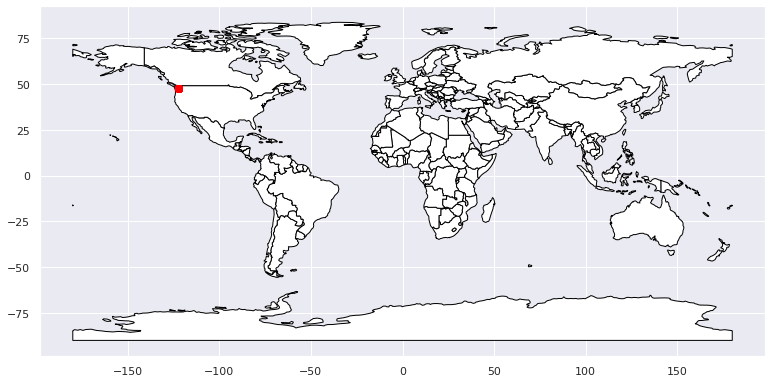

In [31]:
ax = countries.plot(
    color='white', edgecolor='black')

# plot``GeoDataFrame``.
gdf.plot(ax=ax, color='red')

plt.show()

In [32]:
mean_lat = df['Latitude'].describe()['mean']
mean_lat

47.62403312098933

In [33]:
mean_lon = df['Longitude'].describe()['mean']
mean_lon

-122.33479519780805

In [34]:
#place_name = 'Seattle, USA'
#tags = {'building': True}
#area = ox.geometries.geometries_from_place(place_name, tags)
#area.plot()

In [35]:
map = folium.Map(location=[mean_lat, mean_lon], zoom_start=11)

locations = df[['Latitude', 'Longitude']]
locationlist = locations.values.tolist()

for coord in locationlist:
    folium.Marker(
            location=[ coord[0], coord[1] ], 
            fill_color='#43d9de', radius=8).add_to(map)

map.save( 'map_s.html')

In [36]:
## uncomment "map" to display map

# map

In [37]:
### avec coordonnées vérifier existence de quartiers / groupes

In [38]:
# folium doc : https://python-visualization.github.io/folium/modules.html
# article : https://towardsdatascience.com/folium-mapping-displaying-markers-on-a-map-6bd56f3e3420

In [39]:
colors_list = ['beige', 'black', 'blue', 'cadetblue', 'darkblue', 'darkgreen', 'darkpurple', 
 'darkred', 'gray', 'green', 'lightblue', 'lightgray', 'lightgreen', 'lightred', 
 'orange', 'pink', 'purple', 'red', 'white']

In [40]:
len(colors_list)

19

In [41]:
df['Neighborhood'].nunique()

19

In [42]:
df['Neighborhood'].nunique()

19

In [43]:
cat_cols = df.columns[df.dtypes == 'object']
cat_cols

Index(['BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address',
       'City', 'State', 'TaxParcelIdentificationNumber', 'Neighborhood',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType',
       'YearsENERGYSTARCertified', 'ComplianceStatus', 'Outlier'],
      dtype='object')

In [44]:
df[cat_cols].describe()

,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,TaxParcelIdentificationNumber,Neighborhood,ListOfAllPropertyUseTypes,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,YearsENERGYSTARCertified,ComplianceStatus,Outlier
count,3376,3376,3376,3376,3376,3376,3376,3376,3367,3356,1679,596,119,3376,32
unique,8,24,3362,3354,1,1,3268,19,466,56,50,44,65,4,2
top,NonResidential,Low-Rise Multifamily,Northgate Plaza,2600 SW Barton St,Seattle,WA,1625049001,DOWNTOWN,Multifamily Housing,Multifamily Housing,Parking,Retail Store,2016,Compliant,Low outlier
freq,1460,987,3,4,3376,3376,8,573,866,1667,976,110,14,3211,23


In [45]:
quartiers = df['Neighborhood'].unique()
quartiers

array(['DOWNTOWN', 'SOUTHEAST', 'NORTHEAST', 'EAST', 'Central', 'NORTH',
       'MAGNOLIA / QUEEN ANNE', 'LAKE UNION', 'GREATER DUWAMISH',
       'BALLARD', 'NORTHWEST', 'CENTRAL', 'SOUTHWEST', 'DELRIDGE',
       'Ballard', 'North', 'Delridge', 'Northwest',
       'DELRIDGE NEIGHBORHOODS'], dtype=object)

In [46]:
df['Neighborhood'].value_counts()

DOWNTOWN                  573
EAST                      453
MAGNOLIA / QUEEN ANNE     423
GREATER DUWAMISH          375
NORTHEAST                 280
LAKE UNION                251
NORTHWEST                 210
SOUTHWEST                 166
NORTH                     145
BALLARD                   126
CENTRAL                   107
SOUTHEAST                  95
DELRIDGE                   80
North                      42
Central                    27
Northwest                  11
Ballard                     7
Delridge                    4
DELRIDGE NEIGHBORHOODS      1
Name: Neighborhood, dtype: int64

In [47]:
df['Neighborhood'] = df['Neighborhood'].str.upper()
df['Neighborhood'].loc[df['Neighborhood'] == 'DELRIDGE NEIGHBORHOODS'] = 'DELRIDGE'

In [48]:
df['Neighborhood'].value_counts()

DOWNTOWN                 573
EAST                     453
MAGNOLIA / QUEEN ANNE    423
GREATER DUWAMISH         375
NORTHEAST                280
LAKE UNION               251
NORTHWEST                221
NORTH                    187
SOUTHWEST                166
CENTRAL                  134
BALLARD                  133
SOUTHEAST                 95
DELRIDGE                  85
Name: Neighborhood, dtype: int64

In [49]:
## => dict fonction zip

In [50]:
dict_cols = dict(zip(quartiers, colors_list))

dict_cols

{'DOWNTOWN': 'beige',
 'SOUTHEAST': 'black',
 'NORTHEAST': 'blue',
 'EAST': 'cadetblue',
 'Central': 'darkblue',
 'NORTH': 'darkgreen',
 'MAGNOLIA / QUEEN ANNE': 'darkpurple',
 'LAKE UNION': 'darkred',
 'GREATER DUWAMISH': 'gray',
 'BALLARD': 'green',
 'NORTHWEST': 'lightblue',
 'CENTRAL': 'lightgray',
 'SOUTHWEST': 'lightgreen',
 'DELRIDGE': 'lightred',
 'Ballard': 'orange',
 'North': 'pink',
 'Delridge': 'purple',
 'Northwest': 'red',
 'DELRIDGE NEIGHBORHOODS': 'white'}

In [51]:
dict_cols.values()

dict_values(['beige', 'black', 'blue', 'cadetblue', 'darkblue', 'darkgreen', 'darkpurple', 'darkred', 'gray', 'green', 'lightblue', 'lightgray', 'lightgreen', 'lightred', 'orange', 'pink', 'purple', 'red', 'white'])

In [52]:
dict_cols["DOWNTOWN"]

'beige'

In [53]:
for i,row in df.iterrows():
    #Setup the content of the popup
    iframe = folium.IFrame(f'Neighborhood: {str(row["Neighborhood"])} \n Type: {str(row["PrimaryPropertyType"])}')
    
    #Initialise the popup using the iframe
    popup = folium.Popup(iframe, min_width=300, max_width=300)
    
    try:
        icon_color = dict_cols[row['Neighborhood']]
    except:
        #Catch nans
        icon_color = 'gray'
    
    #Add each row to the map
    folium.Marker(location=[row['Latitude'],row['Longitude']],
                  popup = popup, 
                  icon=folium.Icon(color=icon_color, icon='')).add_to(map)
    
    

In [54]:
## uncomment "map" to display map

map

# Cleaning

## Distribution pre-cleaning

### Fonctions

In [55]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev

  #Plotting the variable with every information
  sns.kdeplot(data[i], shade=True)
  sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
  sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
  sns.scatterplot([mean], [0], color = 'red', label = "mean")
  sns.scatterplot([median], [0], color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [56]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


### Infos

Description cols/features : https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

In [57]:
import utils.UVA as UVA
import utils.MVA as MVA

In [58]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['ZipCode', 'Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'Comments', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'],
      dtype='object')

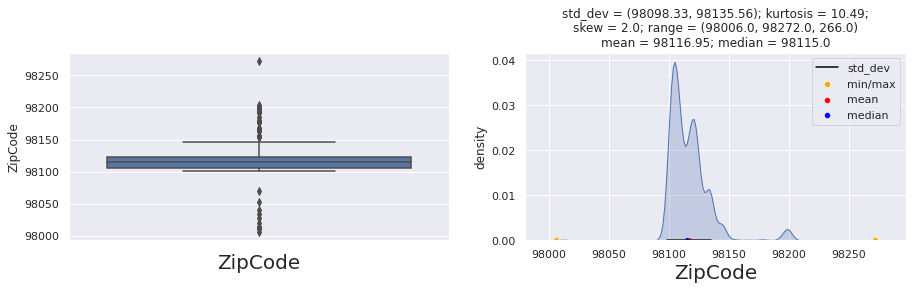

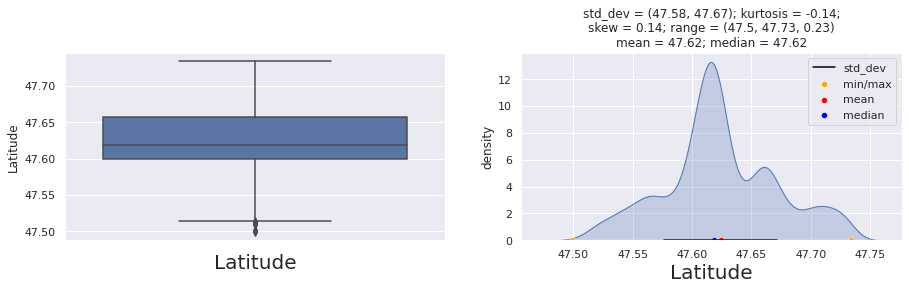

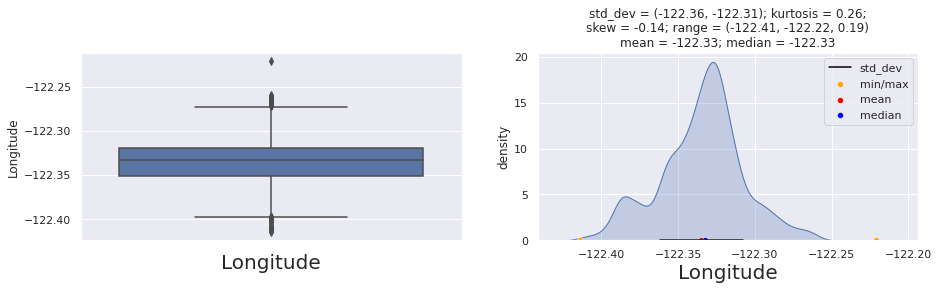

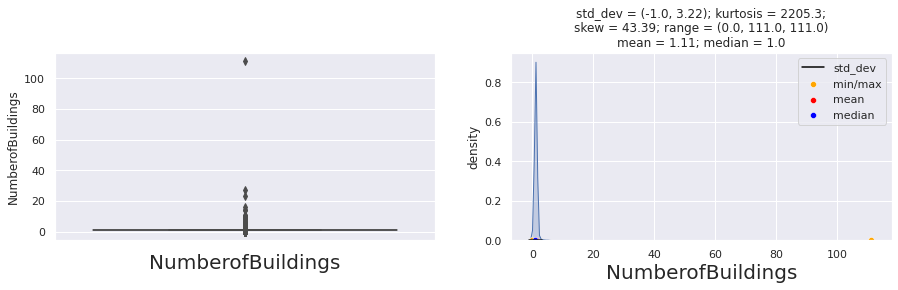

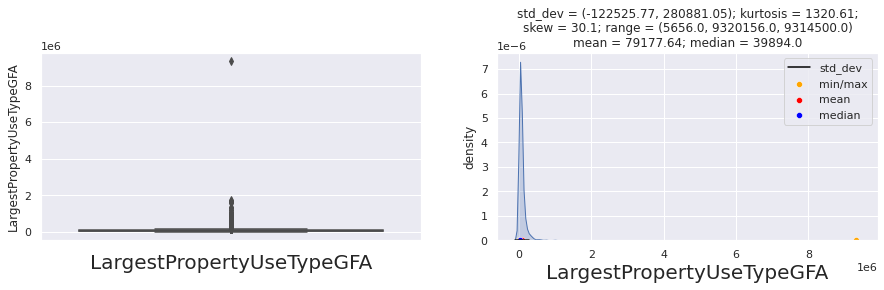

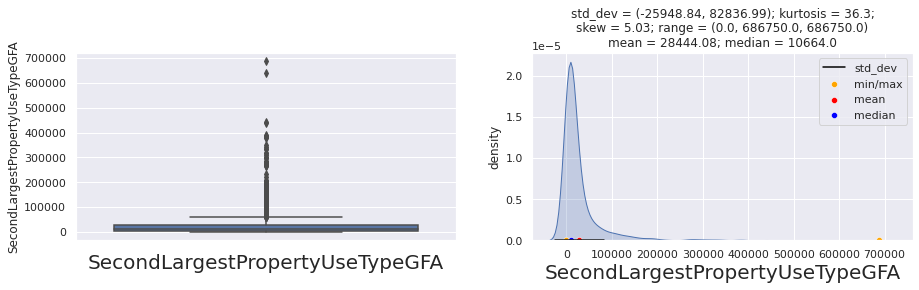

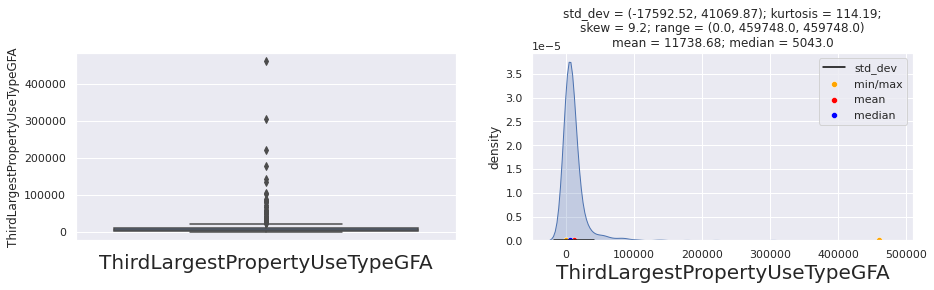

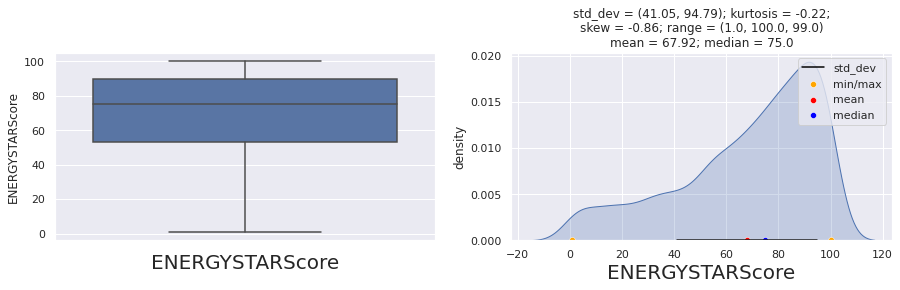

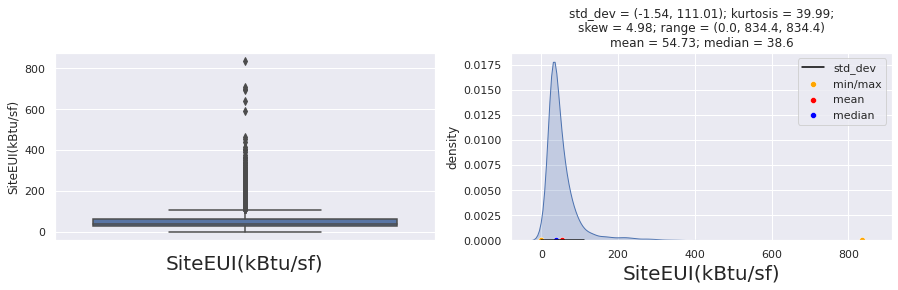

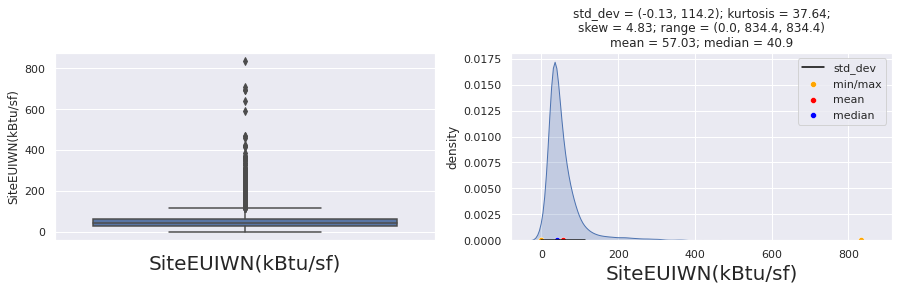

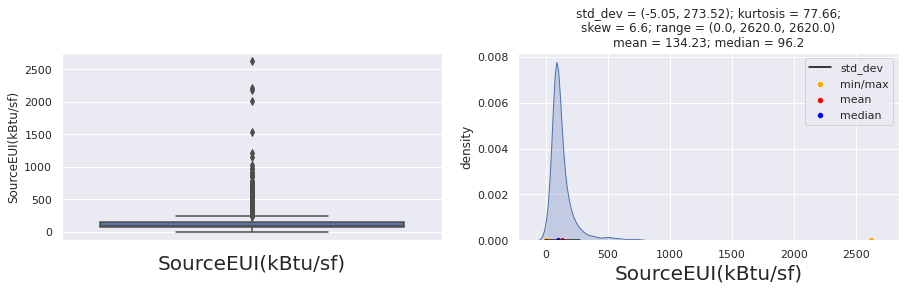

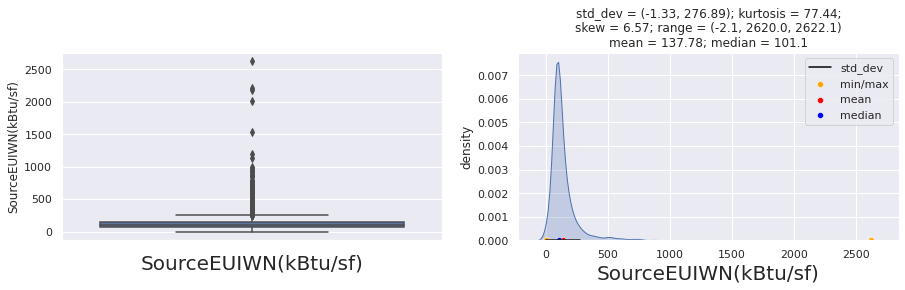

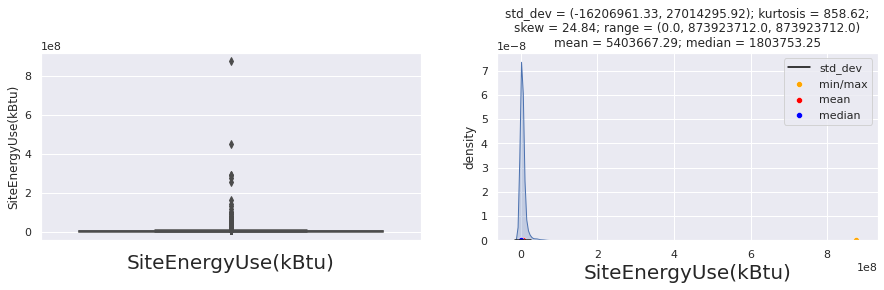

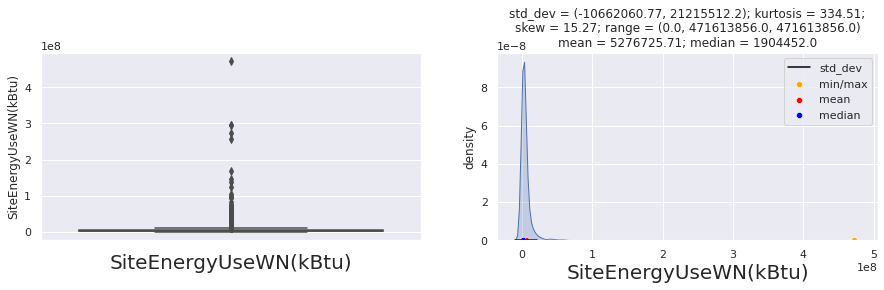

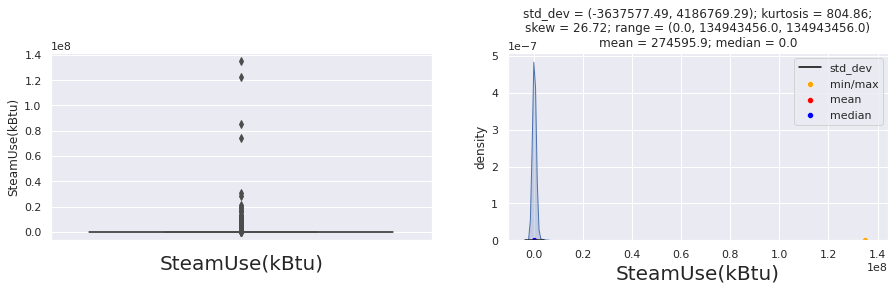

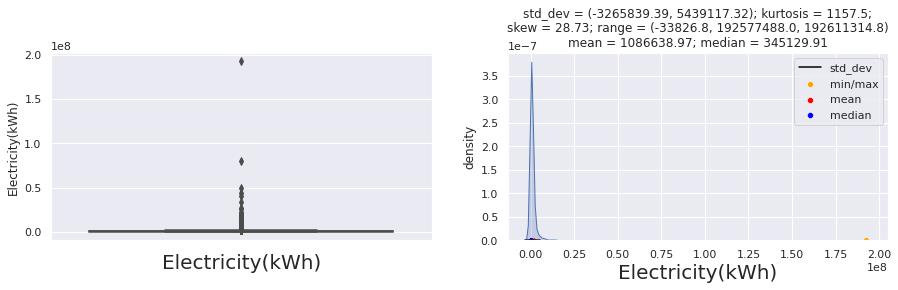

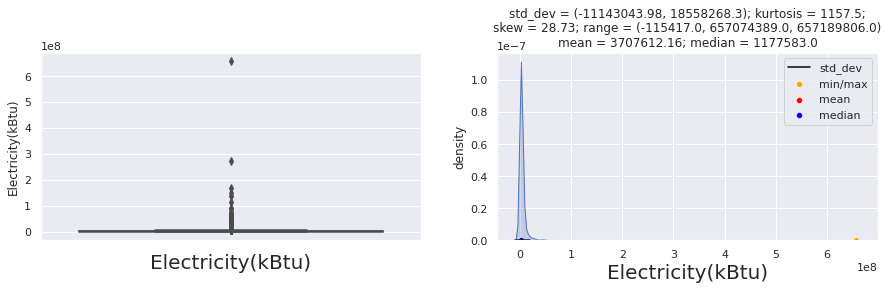

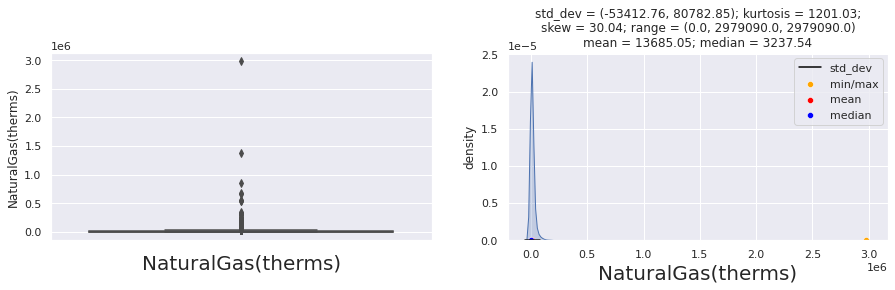

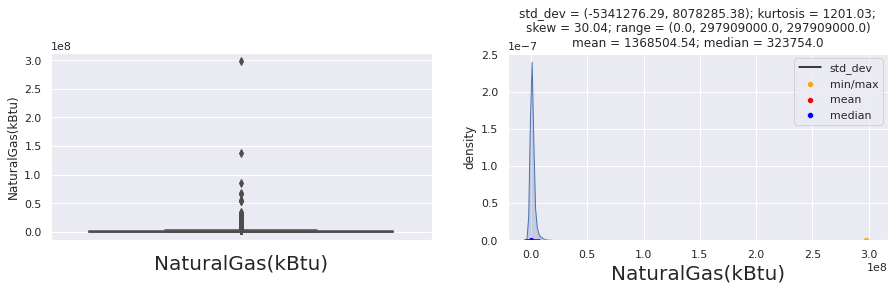

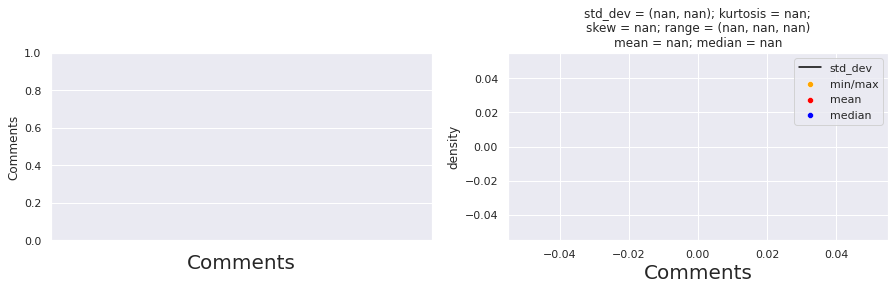

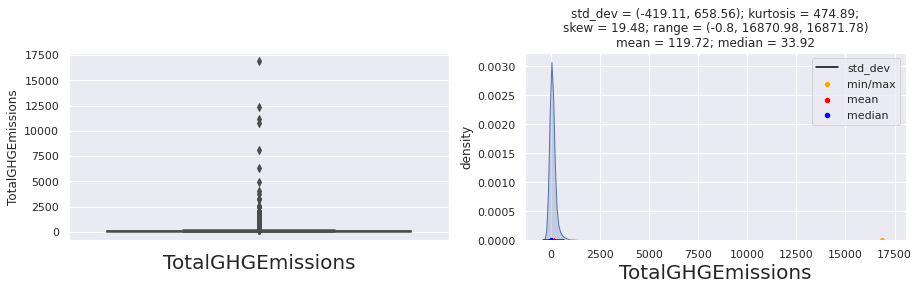

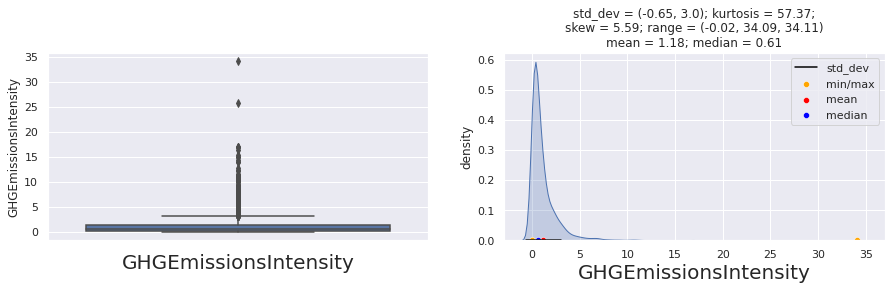

In [59]:
UVA_num_plus(df, num_cols)

In [60]:
num_cols

Index(['ZipCode', 'Latitude', 'Longitude', 'NumberofBuildings',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'Comments', 'TotalGHGEmissions',
       'GHGEmissionsIntensity'],
      dtype='object')

In [61]:
df['NumberofBuildings'].value_counts()

1.0      3175
0.0        92
2.0        37
3.0        22
4.0        12
5.0        10
6.0         5
8.0         3
10.0        2
14.0        2
9.0         2
7.0         1
11.0        1
16.0        1
23.0        1
27.0        1
111.0       1
Name: NumberofBuildings, dtype: int64

In [62]:
# si volonté de réduire skewness => faire log
# bonus : faire log pour comparer (s'approche de la distribution normale)
# skewness négative => check doc

## Feature reduction

In [63]:
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


### Retrait colonne 'Outlier'


In [64]:
df.shape

(3376, 46)

In [65]:
df['Outlier'].head()

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: Outlier, dtype: object

In [66]:
df = df[df['Outlier'].isnull()]

In [67]:
df.shape

(3344, 46)

In [68]:
df['Outlier'].value_counts()

Series([], Name: Outlier, dtype: int64)

### PropertyName

In [69]:
df['PropertyName'].nunique()

3330

In [70]:
df['PropertyName'].unique()

array(['Mayflower park hotel', 'Paramount Hotel',
       '5673-The Westin Seattle', ..., 'Queen Anne Pool',
       'South Park Community Center', 'Van Asselt Community Center'],
      dtype=object)

In [71]:
# => to delete, is unique / pretty much and ID

### Retrait des colonnes non-utilisables / redondantes

In [72]:
df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [73]:
#df['geometry'].nunique()

In [74]:
cols_to_drop = [
    'DataYear', #annee collecte donnees
    'OSEBuildingID', # inutilisé
    'City', #une seule valeur unique
    'State', #une seule valeur unique
    'PropertyName', #inutilisé, nom de la propriété
    'TaxParcelIdentificationNumber', #inutilisé
    'Address', #redondant avec latitude / longitude
    #'ZipCode', #redondant avec adresse
    'CouncilDistrictCode', #redondant adresse
    'Latitude', #redondant adresse
    'Longitude', #redondant adresse
    #'Neighborhood',
    'Comments', # 100% de données manquantes
    'Outlier', # 99% de données manquantes, a permis de retirer précedemment les lignes libellées "outlier"
    'YearsENERGYSTARCertified', #96.5% de données manquantes
    #'ENERGYSTARScore', # 25% de données manquantes, à garder pour évaluer si il permet d'améliorer pred ou pas des modèles
    'ListOfAllPropertyUseTypes' # redondant
]

In [75]:
df.shape

(3344, 46)

In [76]:
cols_to_drop += [
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA',
    'ThirdLargestPropertyUseTypeGFA',
    'ComplianceStatus',
    'DefaultData',
    #'geometry'
]

In [77]:
cols_to_drop += [
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    #'SiteEnergyUse(kBtu)',
    'SiteEnergyUseWN(kBtu)', # comporte une prédiction
    'SteamUse(kBtu)',
    'Electricity(kWh)',
    'Electricity(kBtu)',
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'GHGEmissionsIntensity'
]

In [78]:
df['SiteEnergyUse(kBtu)'].nunique()

3322

In [79]:
df['SiteEnergyUse(kBtu)'].value_counts()

0.000000e+00    18
7.226362e+06     1
2.177065e+06     1
1.386445e+06     1
1.331470e+06     1
                ..
5.080146e+05     1
1.010968e+06     1
1.275236e+06     1
3.629066e+06     1
1.152896e+06     1
Name: SiteEnergyUse(kBtu), Length: 3322, dtype: int64

In [80]:
cols_to_drop

['DataYear',
 'OSEBuildingID',
 'City',
 'State',
 'PropertyName',
 'TaxParcelIdentificationNumber',
 'Address',
 'CouncilDistrictCode',
 'Latitude',
 'Longitude',
 'Comments',
 'Outlier',
 'YearsENERGYSTARCertified',
 'ListOfAllPropertyUseTypes',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA',
 'ComplianceStatus',
 'DefaultData',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'GHGEmissionsIntensity']

In [81]:
df.shape

(3344, 46)

In [82]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [83]:
df.shape

(3344, 16)

                                                   columns  count  \
ThirdLargestPropertyUseType    ThirdLargestPropertyUseType   2755   
SecondLargestPropertyUseType  SecondLargestPropertyUseType   1681   
ENERGYSTARScore                            ENERGYSTARScore    834   
LargestPropertyUseType              LargestPropertyUseType     20   
ZipCode                                            ZipCode     16   
TotalGHGEmissions                        TotalGHGEmissions      9   
NumberofBuildings                        NumberofBuildings      8   
SiteEnergyUse(kBtu)                    SiteEnergyUse(kBtu)      5   
BuildingType                                  BuildingType      0   
PrimaryPropertyType                    PrimaryPropertyType      0   
Neighborhood                                  Neighborhood      0   
YearBuilt                                        YearBuilt      0   
NumberofFloors                              NumberofFloors      0   
PropertyGFATotal                  

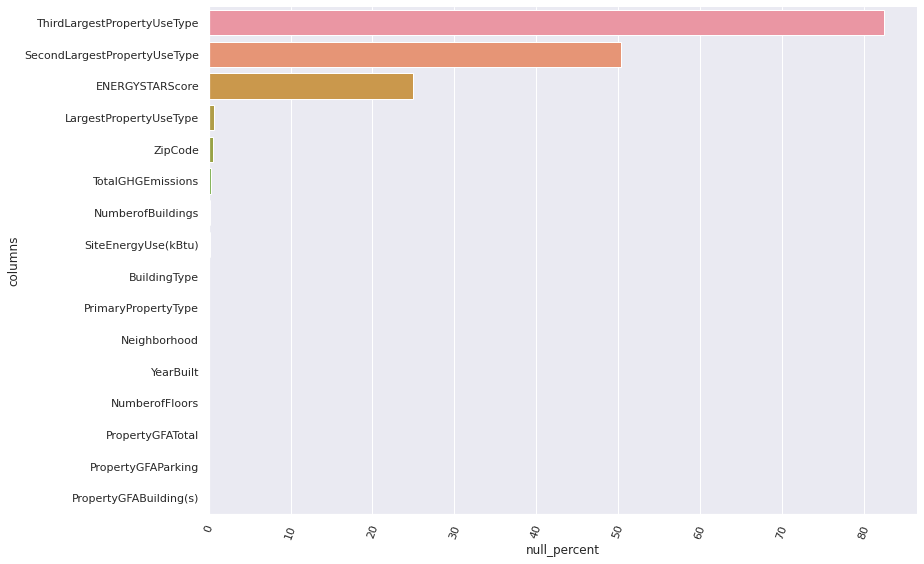

In [84]:
show_nulls(df)

In [85]:
### remplir vides

### garder uniquement batiments non-résidentiels

#### Col BuildingType

In [86]:
cat_cols = df.columns[df.dtypes == 'object']
df[cat_cols].nunique()

BuildingType                     8
PrimaryPropertyType             24
Neighborhood                    13
LargestPropertyUseType          56
SecondLargestPropertyUseType    50
ThirdLargestPropertyUseType     44
dtype: int64

In [87]:
# garder uniquement batiments non-résidentiels
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Multifamily HR (10+)', 'Nonresidential WA'], dtype=object)

In [88]:
# get rows with BuildingType with 'Multifamily' prefix
# count code values with 200 prefix
df['BuildingType'].loc[df['BuildingType'].str.startswith('Multifamily')]

9       Multifamily MR (5-9)
165     Multifamily MR (5-9)
173     Multifamily MR (5-9)
188     Multifamily LR (1-4)
189     Multifamily MR (5-9)
                ...         
3353    Multifamily MR (5-9)
3354    Multifamily MR (5-9)
3355    Multifamily MR (5-9)
3357    Multifamily MR (5-9)
3358    Multifamily LR (1-4)
Name: BuildingType, Length: 1693, dtype: object

In [89]:
df.shape

(3344, 16)

In [90]:
# remove "MultiFamily" related rows
df = df.loc[~df['BuildingType'].str.startswith('Multifamily')]

In [91]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

In [92]:
#df['BuildingType'].unique()

In [93]:
df.shape

(1651, 16)

In [94]:
df['BuildingType'].unique()

array(['NonResidential', 'Nonresidential COS', 'SPS-District K-12',
       'Campus', 'Nonresidential WA'], dtype=object)

In [95]:
df['BuildingType'].value_counts()

NonResidential        1445
SPS-District K-12       97
Nonresidential COS      84
Campus                  24
Nonresidential WA        1
Name: BuildingType, dtype: int64

In [96]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [97]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

#### PrimaryPropertyType

In [98]:
df['PrimaryPropertyType'].isna().sum()

0

In [99]:
df['PrimaryPropertyType'].value_counts()

Small- and Mid-Sized Office    289
Other                          247
Warehouse                      187
Large Office                   170
K-12 School                    137
Mixed Use Property             114
Retail Store                    89
Hotel                           75
Worship Facility                69
Distribution Center             53
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Residence Hall                  21
Senior Care Community           20
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Office                           3
Low-Rise Multifamily             2
Name: PrimaryPropertyType, dtype: int64

In [100]:
df['PrimaryPropertyType'].nunique()

22

In [101]:
search_strings = ["housing", "residence", "residential", "Dormitory", "senior care community", "family"]
df.loc[df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
59,NonResidential,Senior Care Community,98126.0,SOUTHWEST,1922,1.0,5,217603,0,217603,Senior Care Community,Parking,NaN,54.0,4.279207e+07,1727.11
60,NonResidential,Senior Care Community,98133.0,NORTHWEST,1970,1.0,2,93397,0,93397,Senior Care Community,NaN,NaN,1.0,1.640256e+07,609.10
115,NonResidential,Residence Hall,98119.0,MAGNOLIA / QUEEN ANNE,2001,1.0,4,139600,37500,102100,Residence Hall/Dormitory,NaN,NaN,89.0,4.448582e+06,129.39
171,NonResidential,Senior Care Community,98104.0,DOWNTOWN,1999,1.0,5,102796,12611,90185,Senior Care Community,Medical Office,K-12 School,NaN,1.010538e+07,193.94
186,NonResidential,Residence Hall,98101.0,DOWNTOWN,1913,1.0,9,107572,0,107572,Residence Hall/Dormitory,Office,Retail Store,76.0,5.572503e+06,254.87
644,NonResidential,Low-Rise Multifamily,98103.0,LAKE UNION,2000,1.0,3,93079,36093,56986,Multifamily Housing,NaN,NaN,32.0,1.997182e+06,25.60
858,NonResidential,Residence Hall,98105.0,NORTHEAST,1921,1.0,3,21499,0,21499,Residence Hall/Dormitory,NaN,NaN,85.0,6.051307e+05,4.22
888,NonResidential,Senior Care Community,98104.0,EAST,2006,1.0,6,62334,0,62334,Senior Care Community,Bank Branch,Parking,100.0,1.076733e+06,34.98
890,NonResidential,Residence Hall,98105.0,NORTHEAST,1930,1.0,3,20960,0,20960,Residence Hall/Dormitory,NaN,NaN,NaN,1.500310e+06,64.51
934,NonResidential,Residence Hall,98105.0,NORTHEAST,1993,1.0,3,28572,0,28572,Residence Hall/Dormitory,Parking,NaN,16.0,2.717863e+06,89.57


In [102]:
df.loc[df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).count()

43

In [103]:
df.shape

(1651, 16)

In [104]:
df.loc[~df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).count()

1608

In [105]:
df = df.loc[~df['PrimaryPropertyType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [106]:
df.shape

(1608, 16)

##### col LargestPropertyUseType

In [107]:
# fill nas with "No UseType"
df[['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']] = df[['LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']].fillna('No UseType')

In [108]:
df['LargestPropertyUseType'].isna().sum()

0

In [109]:
df['LargestPropertyUseType'].unique()

array(['Hotel', 'Police Station', 'Other - Entertainment/Public Assembly',
       'Library', 'Fitness Center/Health Club/Gym', 'Social/Meeting Hall',
       'Courthouse', 'Other', 'K-12 School', 'College/University',
       'Automobile Dealership', 'Office', 'Self-Storage Facility',
       'Non-Refrigerated Warehouse', 'Other - Mall', 'Medical Office',
       'Retail Store', 'Hospital (General Medical & Surgical)', 'Museum',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Other - Lodging/Residential', 'Other/Specialty Hospital',
       'Financial Office', 'Distribution Center', 'Parking',
       'Multifamily Housing', 'Worship Facility', 'Restaurant',
       'Data Center', 'Laboratory', 'Supermarket/Grocery Store',
       'Convention Center', 'Urgent Care/Clinic/Other Outpatient',
       'No UseType', 'Other - Services', 'Strip Mall',
       'Wholesale Club/Supercenter', 'Refrigerated Warehouse',
       'Manufacturing/Industrial Plant', 'Other - Recreation',
       'L

In [110]:
search_strings = ["housing", "residence", "residential", "dormitory"]
df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings)).sum()

16

In [111]:
df.loc[df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
113,NonResidential,Other,98118.0,GREATER DUWAMISH,2009,1.0,5,89821,0,89821,Other - Lodging/Residential,Office,Food Service,NaN,1.950092e+06,100.46
164,NonResidential,Mixed Use Property,98119.0,MAGNOLIA / QUEEN ANNE,2002,1.0,4,110785,0,110785,Multifamily Housing,Supermarket/Grocery Store,Parking,NaN,1.055791e+07,92.91
1159,NonResidential,Mixed Use Property,98103.0,LAKE UNION,2001,5.0,3,41827,9226,32601,Multifamily Housing,Office,Parking,NaN,4.193371e+06,110.17
1194,Nonresidential COS,Other,98133.0,NORTHWEST,1970,1.0,4,25557,0,25557,Residential Care Facility,No UseType,No UseType,NaN,2.280352e+06,15.90
1839,NonResidential,Mixed Use Property,98104.0,DOWNTOWN,1913,1.0,3,43878,0,43878,Multifamily Housing,Office,Retail Store,NaN,7.697713e+05,5.37
1928,NonResidential,Other,98134.0,GREATER DUWAMISH,1992,1.0,3,47836,7572,40264,Other - Lodging/Residential,Parking,No UseType,NaN,3.540226e+06,109.59
2314,NonResidential,Mixed Use Property,98101.0,DOWNTOWN,2009,1.0,39,1074552,112124,962428,Multifamily Housing,Hotel,Parking,65.0,2.641677e+07,449.59
2394,NonResidential,Mixed Use Property,98105.0,NORTHEAST,1997,1.0,4,32282,6985,25297,Multifamily Housing,Parking,Other,NaN,1.391714e+06,34.62
2407,NonResidential,Mixed Use Property,98104.0,DOWNTOWN,2005,0.0,5,57600,0,57600,Residence Hall/Dormitory,Multifamily Housing,Financial Office,NaN,6.983736e+06,223.36
2711,NonResidential,Other,98104.0,DOWNTOWN,1904,1.0,6,29820,0,29820,Other - Lodging/Residential,No UseType,No UseType,NaN,1.601956e+06,35.72


In [112]:
df.shape

(1608, 16)

In [113]:
df.loc[df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

16

In [114]:
df.loc[~df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

1592

In [115]:
df = df.loc[~df['LargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [116]:
df.shape

(1592, 16)

#### SecondLargestPropertyUseType

In [117]:
df['SecondLargestPropertyUseType'].isna().sum()

0

In [118]:
df.shape

(1592, 16)

In [119]:
df['SecondLargestPropertyUseType'].unique()

array(['No UseType', 'Parking', 'Office', 'Restaurant', 'K-12 School',
       'Laboratory', 'Refrigerated Warehouse',
       'Non-Refrigerated Warehouse', 'Other - Education',
       'Vocational School', 'Retail Store',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Entertainment/Public Assembly', 'Data Center',
       'Swimming Pool', 'Other', 'Courthouse', 'Residence Hall/Dormitory',
       'Distribution Center', 'Self-Storage Facility', 'Other - Services',
       'Movie Theater', 'Other - Recreation',
       'Convenience Store without Gas Station', 'Performing Arts',
       'College/University', 'Supermarket/Grocery Store',
       'Other - Restaurant/Bar', 'Adult Education', 'Medical Office',
       'Enclosed Mall', 'Multifamily Housing', 'Bar/Nightclub',
       'Financial Office',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Manufacturing/Industrial Plant', 'Other - Lodging/Residential',
       'Bank Branch', 'Fitness Center/Heal

In [120]:
search_strings = ["housing", "residence", "residential", "dormitory"]
df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings)).sum()

13

In [121]:
df.loc[df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
146,Nonresidential COS,Warehouse,98109.0,MAGNOLIA / QUEEN ANNE,1926,1.0,2,50292,0,50292,Non-Refrigerated Warehouse,Residence Hall/Dormitory,Office,NaN,4.304737e+05,3.00
488,NonResidential,Mixed Use Property,98121.0,DOWNTOWN,2006,0.0,0,516407,0,516407,Parking,Multifamily Housing,Hotel,31.0,3.940332e+07,734.72
511,NonResidential,Large Office,98134.0,GREATER DUWAMISH,2007,1.0,1,158931,28381,130550,Office,Multifamily Housing,Parking,12.0,8.751704e+06,98.54
541,NonResidential,Mixed Use Property,98134.0,GREATER DUWAMISH,1930,3.0,2,108753,18860,89893,Non-Refrigerated Warehouse,Multifamily Housing,Retail Store,NaN,3.639670e+06,25.37
731,NonResidential,Small- and Mid-Sized Office,98121.0,DOWNTOWN,1917,1.0,2,21600,0,21600,Office,Other - Lodging/Residential,No UseType,NaN,1.636649e+06,29.62
912,NonResidential,Mixed Use Property,98107.0,BALLARD,1960,1.0,4,20539,0,20539,Retail Store,Multifamily Housing,Restaurant,NaN,1.678459e+06,37.31
922,NonResidential,Other,98105.0,NORTHEAST,1921,1.0,3,29636,0,29636,Other - Entertainment/Public Assembly,Multifamily Housing,No UseType,NaN,6.886418e+05,4.80
1167,NonResidential,Small- and Mid-Sized Office,98103.0,LAKE UNION,1981,1.0,2,22388,0,22388,Office,Multifamily Housing,No UseType,NaN,5.764051e+05,9.46
1315,NonResidential,Mixed Use Property,98121.0,DOWNTOWN,1910,1.0,3,29340,0,29340,Office,Multifamily Housing,Restaurant,NaN,2.160420e+06,75.99
1773,NonResidential,Mixed Use Property,98011.0,DOWNTOWN,1909,1.0,11,111137,0,111137,Office,Multifamily Housing,Bank Branch,NaN,9.546165e+06,294.65


In [122]:
df.shape

(1592, 16)

In [123]:
df.loc[df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

13

In [124]:
df.loc[~df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)].any(1).sum()

1579

In [125]:
df = df.loc[~df['SecondLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [126]:
df.shape

(1579, 16)

##### ThirdLargestPropertyUseType

In [127]:
df['ThirdLargestPropertyUseType'].isna().sum()

0

In [128]:
df.shape

(1579, 16)

In [129]:
df['ThirdLargestPropertyUseType'].unique()

array(['No UseType', 'Restaurant', 'Swimming Pool', 'Data Center',
       'Office', 'Retail Store', 'Other - Entertainment/Public Assembly',
       'Non-Refrigerated Warehouse', 'Other', 'Distribution Center',
       'Other - Services', 'Medical Office', 'Parking', 'Food Service',
       'Other - Utility', 'Fitness Center/Health Club/Gym',
       'Social/Meeting Hall', 'Pre-school/Daycare',
       'Convenience Store without Gas Station', 'Financial Office',
       'Other - Restaurant/Bar', 'Other - Education',
       'Multifamily Housing', 'Laboratory', 'Bank Branch',
       'Personal Services (Health/Beauty, Dry Cleaning, etc)',
       'Other - Recreation', 'Self-Storage Facility',
       'Other - Technology/Science', 'Refrigerated Warehouse',
       'Bar/Nightclub', 'Manufacturing/Industrial Plant',
       'Other/Specialty Hospital', 'Fast Food Restaurant', 'K-12 School',
       'Supermarket/Grocery Store', 'Strip Mall', 'Vocational School'],
      dtype=object)

In [130]:
search_strings = ["housing", "residence", "residential", "dormitory"]
df['ThirdLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings)).sum()

12

In [131]:
df.loc[df['ThirdLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
289,Campus,Mixed Use Property,98101.0,DOWNTOWN,1908,1.0,4,137400,0,137400,Retail Store,Other - Restaurant/Bar,Multifamily Housing,NaN,1.494050e+07,316.20
440,NonResidential,Mixed Use Property,98103.0,LAKE UNION,1904,1.0,2,53002,0,53002,Retail Store,Parking,Multifamily Housing,75.0,3.441643e+06,64.00
466,NonResidential,Small- and Mid-Sized Office,98134.0,GREATER DUWAMISH,1904,1.0,4,58970,0,58970,Office,Non-Refrigerated Warehouse,Multifamily Housing,NaN,1.776412e+06,41.18
612,NonResidential,Mixed Use Property,98105.0,NORTHEAST,2009,1.0,6,122400,54300,68100,Office,Parking,Multifamily Housing,63.0,4.865552e+06,79.39
1328,NonResidential,Mixed Use Property,98109.0,LAKE UNION,2008,1.0,4,274442,0,274442,Hotel,Parking,Multifamily Housing,NaN,9.155568e+06,220.26
1599,NonResidential,Mixed Use Property,98107.0,BALLARD,1909,1.0,3,27085,0,27085,Strip Mall,Office,Multifamily Housing,NaN,1.995132e+06,60.67
2398,NonResidential,Large Office,98104.0,DOWNTOWN,1983,1.0,13,307557,83064,224493,Office,Parking,Multifamily Housing,NaN,9.512829e+06,66.32
2506,NonResidential,Small- and Mid-Sized Office,98121.0,DOWNTOWN,1989,1.0,7,47415,0,47415,Office,Parking,Multifamily Housing,NaN,1.478979e+06,10.31
2759,NonResidential,Small- and Mid-Sized Office,98104.0,DOWNTOWN,1909,1.0,3,31432,0,31432,Office,Other,Multifamily Housing,NaN,1.439572e+06,10.04
3134,NonResidential,Mixed Use Property,98102.0,EAST,1916,1.0,2,140823,59401,81422,Parking,Supermarket/Grocery Store,Multifamily Housing,NaN,2.762846e+06,28.85


In [132]:
df = df.loc[~df['ThirdLargestPropertyUseType'].str.lower().str.contains('|'.join(search_strings), na=False)]

In [133]:
df.shape

(1567, 16)

In [134]:
df.columns


Index(['BuildingType', 'PrimaryPropertyType', 'ZipCode', 'Neighborhood',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType', 'ENERGYSTARScore', 'SiteEnergyUse(kBtu)',
       'TotalGHGEmissions'],
      dtype='object')

### Categories reduction

In [135]:
cat_cols.unique()

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType'],
      dtype='object')

In [136]:
# => réencoder manuellement en classes générales

In [137]:
# identifier tous les types uniques de bâtiments parmi les 3 listes

In [138]:
PropLargest = df['LargestPropertyUseType'].unique()
PropSecond = df['SecondLargestPropertyUseType'].unique()
PropThird = df['ThirdLargestPropertyUseType'].unique()

In [139]:
MergeList = np.concatenate((PropLargest, PropSecond, PropThird))

In [140]:
len(np.unique(MergeList))

60

In [141]:
np.unique(MergeList)

array(['Adult Education', 'Automobile Dealership', 'Bank Branch',
       'Bar/Nightclub', 'College/University',
       'Convenience Store without Gas Station', 'Convention Center',
       'Courthouse', 'Data Center', 'Distribution Center',
       'Enclosed Mall', 'Fast Food Restaurant', 'Financial Office',
       'Fire Station', 'Fitness Center/Health Club/Gym', 'Food Sales',
       'Food Service', 'Hospital (General Medical & Surgical)', 'Hotel',
       'K-12 School', 'Laboratory', 'Library', 'Lifestyle Center',
       'Manufacturing/Industrial Plant', 'Medical Office',
       'Movie Theater', 'Museum', 'No UseType',
       'Non-Refrigerated Warehouse', 'Office', 'Other',
       'Other - Education', 'Other - Entertainment/Public Assembly',
       'Other - Mall', 'Other - Public Services', 'Other - Recreation',
       'Other - Restaurant/Bar', 'Other - Services',
       'Other - Technology/Science', 'Other - Utility',
       'Other/Specialty Hospital', 'Parking', 'Performing Arts',
   

In [142]:
cat_cols = df.columns[df.dtypes == 'object']
df[cat_cols].nunique()

BuildingType                     5
PrimaryPropertyType             19
Neighborhood                    13
LargestPropertyUseType          52
SecondLargestPropertyUseType    45
ThirdLargestPropertyUseType     37
dtype: int64

In [143]:
property_cols = ['LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType']

In [144]:
df['LargestPropertyUseType'].unique()

array(['Hotel', 'Police Station', 'Other - Entertainment/Public Assembly',
       'Library', 'Fitness Center/Health Club/Gym', 'Social/Meeting Hall',
       'Courthouse', 'Other', 'K-12 School', 'College/University',
       'Automobile Dealership', 'Office', 'Self-Storage Facility',
       'Non-Refrigerated Warehouse', 'Other - Mall', 'Medical Office',
       'Retail Store', 'Hospital (General Medical & Surgical)', 'Museum',
       'Repair Services (Vehicle, Shoe, Locksmith, etc)',
       'Other/Specialty Hospital', 'Financial Office',
       'Distribution Center', 'Parking', 'Worship Facility', 'Restaurant',
       'Data Center', 'Laboratory', 'Supermarket/Grocery Store',
       'Convention Center', 'Urgent Care/Clinic/Other Outpatient',
       'No UseType', 'Other - Services', 'Strip Mall',
       'Wholesale Club/Supercenter', 'Refrigerated Warehouse',
       'Manufacturing/Industrial Plant', 'Other - Recreation',
       'Lifestyle Center', 'Other - Public Services', 'Other - Educati

In [145]:
social_entertainement = [
                        'Other - Entertainment/Public Assembly',
                        'Worship Facility',
                        'Restaurant',
                        'Convention Center',
                        'Social/Meeting Hall',
                        'Fitness Center/Health Club/Gym',
                        'Bar/Nightclub',
                        'Convention Center',
                        'Lifestyle Center',
                        'Movie Theater',
                        'Other - Entertainment/Public Assembly',
                        'Performing Arts',
                        'Social/Meeting Hall',
                        'Worship Facility'
                    ]
# df[property_cols].replace(social_entertainement, 'Social / Entertainement', inplace=True)
#df.update(df.loc[:,property_cols]).replace(social_entertainement, "Social / Entertainement")
#df.loc[:,property_cols] = df.loc[:,property_cols].replace(social_entertainement, 'Social / Entertainement')

In [146]:
education_facilities = [
                        'K-12 School',
                        'College/University',
                        'Library',
                        'Museum',
                        'Adult Education',
                        'Other - Education',
                        'Pre-school/Daycare',
                        'Vocational School'
                    ]
#df[property_cols].replace(education_facilities, 'Education Facility', inplace=True)

In [147]:
shops_services = [
                'Other - Mall',
                'Retail Store',
                'Automobile Dealership',
                'Supermarket/Grocery Store',
                'Repair Services (Vehicle, Shoe, Locksmith, etc)'
                'Distribution Center',
                'Automobile Dealership',
                'Bank Branch',
                'Convenience Store without Gas Station',
                'Enclosed Mall',
                'Fast Food Restaurant',
                'Food Sales',
                'Food Service',
                'Hotel',
                'Other - Mall',
                'Other - Recreation', 
                'Other - Restaurant/Bar',
                'Other - Services',
                'Other - Utility',
                'Personal Services (Health/Beauty, Dry Cleaning, etc)',
                'Repair Services (Vehicle, Shoe, Locksmith, etc)',
                'Restaurant',
                'Retail Store',
                'Self-Storage Facility',
                'Strip Mall',
                'Supermarket/Grocery Store',
                'Swimming Pool',
                'Wholesale Club/Supercenter'
                ]
#df[property_cols].replace(shops_services, 'Shops / Services', inplace=True)

In [148]:
health_facilities = [
                    'Other/Specialty Hospital',
                    'Hospital (General Medical & Surgical)',
                    'Medical Office',
                    'Other/Specialty Hospital',
                    'Urgent Care/Clinic/Other Outpatient'
]
#df[property_cols].replace(health_facilities, 'health_facilities', inplace=True)

In [149]:
public_services = [
                'Courthouse',
                'Fire Station',
                'Library',
                'Museum',
                'Other - Public Services',
                'Police Station',
                'Prison/Incarceration',
    
]
#df[property_cols].replace(public_services, 'Public Services', inplace=True)

In [150]:
industry_offices = [
                'Office',
                'Financial Office', 
                'Distribution Center',
                'Data Center',
                'Laboratory',
                'Manufacturing/Industrial Plant',
                'Non-Refrigerated Warehouse',
                'Refrigerated Warehouse'
]
#df[property_cols].replace(industry_offices, 'Industry / Offices', inplace=True)

In [151]:
# 

In [152]:
#df[property_cols].replace(health_facilities, 'health_facilities', inplace=True)
#df[property_cols].replace(public_services, 'Public Services', inplace=True)
#df[property_cols].replace(shops_services, 'Shops / Services', inplace=True)
#df[property_cols].replace(industry_offices, 'Industry / Offices', inplace=True)
#df[property_cols].replace(education_facilities, 'Education Facility', inplace=True)
#df[property_cols].replace(social_entertainement, 'Social / Entertainement', inplace=True)

In [153]:
df.loc[:,property_cols] = df.loc[:,property_cols].replace(health_facilities, 'health_facilities')
df.loc[:,property_cols] = df.loc[:,property_cols].replace(public_services, 'Public Services')
df.loc[:,property_cols] = df.loc[:,property_cols].replace(shops_services, 'Shops / Services')
df.loc[:,property_cols] = df.loc[:,property_cols].replace(industry_offices, 'Industry / Offices')
df.loc[:,property_cols] = df.loc[:,property_cols].replace(education_facilities, 'Education Facility')
df.loc[:,property_cols] = df.loc[:,property_cols].replace(social_entertainement, 'Social / Entertainement')

In [154]:
df[property_cols]

,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,Shops / Services,No UseType,No UseType
1,Shops / Services,Parking,Shops / Services
2,Shops / Services,No UseType,No UseType
3,Shops / Services,No UseType,No UseType
4,Shops / Services,Parking,Shops / Services
...,...,...,...
3371,Industry / Offices,No UseType,No UseType
3372,Shops / Services,No UseType,No UseType
3373,Shops / Services,Social / Entertainement,Shops / Services
3374,Shops / Services,Social / Entertainement,Education Facility


In [155]:
df[cat_cols].nunique()

BuildingType                     5
PrimaryPropertyType             19
Neighborhood                    13
LargestPropertyUseType           9
SecondLargestPropertyUseType     9
ThirdLargestPropertyUseType      9
dtype: int64

In [156]:
df['LargestPropertyUseType'].unique()

array(['Shops / Services', 'Public Services', 'Social / Entertainement',
       'Other', 'Education Facility', 'Industry / Offices',
       'health_facilities', 'Parking', 'No UseType'], dtype=object)

In [157]:
health_facilities

['Other/Specialty Hospital',
 'Hospital (General Medical & Surgical)',
 'Medical Office',
 'Other/Specialty Hospital',
 'Urgent Care/Clinic/Other Outpatient']

In [158]:
df['SecondLargestPropertyUseType'].unique()

array(['No UseType', 'Parking', 'Industry / Offices', 'Shops / Services',
       'Education Facility', 'Social / Entertainement', 'Other',
       'Public Services', 'health_facilities'], dtype=object)

In [159]:
df['ThirdLargestPropertyUseType'].unique()

array(['No UseType', 'Shops / Services', 'Industry / Offices',
       'Social / Entertainement', 'Other', 'health_facilities', 'Parking',
       'Education Facility', 'Other - Technology/Science'], dtype=object)

In [160]:
# check list

In [161]:
# use UPDATE not REPLACE
# https://stackoverflow.com/questions/50839121/pandas-replace-not-working-as-expected-on-multiple-column-subset


In [162]:
PropLargest2 = df['LargestPropertyUseType'].unique()
PropSecond2 = df['SecondLargestPropertyUseType'].unique()
PropThird2 = df['ThirdLargestPropertyUseType'].unique()

In [163]:
MergeList = np.concatenate((PropLargest2, PropSecond2, PropThird2))

In [164]:
len(np.unique(MergeList))

10

In [165]:
np.unique(MergeList).tolist()

['Education Facility',
 'Industry / Offices',
 'No UseType',
 'Other',
 'Other - Technology/Science',
 'Parking',
 'Public Services',
 'Shops / Services',
 'Social / Entertainement',
 'health_facilities']

## données aberrantes / normalisation

### Valeurs catégorielles

#### General infos

In [166]:
cat_cols = df.columns[df.dtypes == 'object']
cat_cols

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType'],
      dtype='object')

In [167]:
df[cat_cols].describe()

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
count,1567,1567,1567,1567,1567,1567
unique,5,19,13,9,9,9
top,NonResidential,Small- and Mid-Sized Office,GREATER DUWAMISH,Industry / Offices,No UseType,No UseType
freq,1365,283,337,767,774,1255


In [168]:
df[cat_cols]

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType
0,NonResidential,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
1,NonResidential,Hotel,DOWNTOWN,Shops / Services,Parking,Shops / Services
2,NonResidential,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
3,NonResidential,Hotel,DOWNTOWN,Shops / Services,No UseType,No UseType
4,NonResidential,Hotel,DOWNTOWN,Shops / Services,Parking,Shops / Services
...,...,...,...,...,...,...
3371,Nonresidential COS,Office,GREATER DUWAMISH,Industry / Offices,No UseType,No UseType
3372,Nonresidential COS,Other,DOWNTOWN,Shops / Services,No UseType,No UseType
3373,Nonresidential COS,Other,MAGNOLIA / QUEEN ANNE,Shops / Services,Social / Entertainement,Shops / Services
3374,Nonresidential COS,Mixed Use Property,GREATER DUWAMISH,Shops / Services,Social / Entertainement,Education Facility


In [169]:
#df['ENERGYSTARScore'].value_counts()

In [170]:
def print_cats(df, cat_cols):
    for column in cat_cols:
        print('--------------------------------------------')
        print('--------------------------------------------')
        print(f'Column : {column}')
        print('----')
        #print(df[f'{column}'].value_counts())
        nunique = df[f'{column}'].nunique()
        uni_list = df[f'{column}'].unique()
        #print(sorted(uni_list))
        print(f'nunique : {nunique}')
        print(uni_list)
        print('')
        print('')

In [171]:
print_cats(df, cat_cols)

--------------------------------------------
--------------------------------------------
Column : BuildingType
----
nunique : 5
['NonResidential' 'Nonresidential COS' 'SPS-District K-12' 'Campus'
 'Nonresidential WA']


--------------------------------------------
--------------------------------------------
Column : PrimaryPropertyType
----
nunique : 19
['Hotel' 'Other' 'Mixed Use Property' 'K-12 School' 'University'
 'Small- and Mid-Sized Office' 'Self-Storage Facility' 'Warehouse'
 'Large Office' 'Medical Office' 'Retail Store' 'Hospital'
 'Distribution Center' 'Worship Facility' 'Supermarket / Grocery Store'
 'Laboratory' 'Refrigerated Warehouse' 'Restaurant' 'Office']


--------------------------------------------
--------------------------------------------
Column : Neighborhood
----
nunique : 13
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'EAST' 'CENTRAL' 'NORTH'
 'MAGNOLIA / QUEEN ANNE' 'LAKE UNION' 'GREATER DUWAMISH' 'BALLARD'
 'NORTHWEST' 'SOUTHWEST' 'DELRIDGE']


------------------

#### Neighborhood

In [172]:
#df['ENERGYSTARScore'].value_counts()

In [173]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [174]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

In [175]:
#df['Neighborhood'].value_counts()
print(sorted(df['Neighborhood'].unique()))

['BALLARD', 'CENTRAL', 'DELRIDGE', 'DOWNTOWN', 'EAST', 'GREATER DUWAMISH', 'LAKE UNION', 'MAGNOLIA / QUEEN ANNE', 'NORTH', 'NORTHEAST', 'NORTHWEST', 'SOUTHEAST', 'SOUTHWEST']


In [176]:
# TotalGHGEmissions

In [177]:
df['Neighborhood'] = df['Neighborhood'].str.upper()
df['Neighborhood'].loc[df['Neighborhood'] == 'DELRIDGE NEIGHBORHOODS'] = 'DELRIDGE'

In [178]:
df['Neighborhood'].value_counts()

GREATER DUWAMISH         337
DOWNTOWN                 334
MAGNOLIA / QUEEN ANNE    144
LAKE UNION               141
EAST                     111
NORTHEAST                108
NORTHWEST                 82
BALLARD                   67
NORTH                     64
CENTRAL                   50
DELRIDGE                  47
SOUTHEAST                 43
SOUTHWEST                 39
Name: Neighborhood, dtype: int64

In [179]:
df['Neighborhood'].nunique()

13

In [180]:
#### PropertyTypes

In [181]:
#df['ENERGYSTARScore'].value_counts()

In [182]:
#from sklearn import preprocessing
#le = preprocessing.LabelEncoder()

In [183]:
#df[cat_cols] = le.fit_transform(df[cat_cols].astype(str))

In [184]:
#df[df.columns[df.isnull().any()]].isnull().sum()

In [185]:
#df[df.columns[df.isnull().any()]].isnull().sum() * 100 / df.shape[0]

In [186]:
df['ThirdLargestPropertyUseType'].unique()

array(['No UseType', 'Shops / Services', 'Industry / Offices',
       'Social / Entertainement', 'Other', 'health_facilities', 'Parking',
       'Education Facility', 'Other - Technology/Science'], dtype=object)

In [187]:
df['ThirdLargestPropertyUseType'].nunique()

9

In [188]:
# check error
#UVA_num_plus(df, ['DefaultData'])

In [189]:
df['SecondLargestPropertyUseType'].unique()

array(['No UseType', 'Parking', 'Industry / Offices', 'Shops / Services',
       'Education Facility', 'Social / Entertainement', 'Other',
       'Public Services', 'health_facilities'], dtype=object)

In [190]:
#df['LargestPropertyUseType'].value_counts()

In [191]:
df['LargestPropertyUseType'].isna().count()

1567

In [192]:
df['SecondLargestPropertyUseType'].nunique()

9

In [193]:
#df['ThirdLargestPropertyUseType'].value_counts()

In [194]:
df['ThirdLargestPropertyUseType'].isna().count()

1567

In [195]:
df.loc[df['LargestPropertyUseType'].isna()]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions


In [196]:
#df['ENERGYSTARScore'].value_counts()

In [197]:
### check valeurs erronnées / outliers (negatives ?)

### Valeurs numériques

In [198]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['ZipCode', 'NumberofBuildings', 'ENERGYSTARScore',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions'],
      dtype='object')

In [199]:
df[num_cols].describe()

,ZipCode,NumberofBuildings,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1551.000000,1565.000000,1035.000000,1.565000e+03,1565.000000
mean,98116.838169,1.175080,65.394203,8.575499e+06,187.637188
std,17.998035,3.020394,28.185987,3.111492e+07,773.398653
min,98006.000000,0.000000,1.000000,0.000000e+00,-0.800000
25%,98105.000000,1.000000,48.500000,1.228114e+06,20.100000
50%,98111.000000,1.000000,73.000000,2.551022e+06,49.250000
75%,98125.000000,1.000000,89.000000,6.859198e+06,138.850000
max,98199.000000,111.000000,100.000000,8.739237e+08,16870.980000


In [200]:
df.sort_values(by='NumberofBuildings', ascending=False).head(50)

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
3274,Campus,University,98105.0,NORTHEAST,1900,111.0,0,9320156,0,9320156,Education Facility,No UseType,No UseType,NaN,8.739237e+08,11140.56
105,Campus,University,98106.0,DELRIDGE,1970,27.0,2,441071,0,441071,Education Facility,No UseType,No UseType,NaN,3.830174e+07,866.23
1862,Campus,Other,98119.0,MAGNOLIA / QUEEN ANNE,1955,23.0,1,260241,0,260241,Other,No UseType,No UseType,NaN,3.401298e+07,565.55
2325,Campus,University,98119.0,MAGNOLIA / QUEEN ANNE,1945,14.0,2,537000,0,537000,Education Facility,No UseType,No UseType,NaN,9.060964e+07,3768.66
162,Campus,Large Office,98108.0,GREATER DUWAMISH,1980,14.0,2,334368,31874,302494,Industry / Offices,Industry / Offices,Shops / Services,NaN,5.346668e+07,748.55
128,Campus,University,98103.0,NORTHWEST,1970,11.0,2,694072,111625,582447,Education Facility,No UseType,No UseType,NaN,3.589148e+07,362.82
1993,Campus,Other,98134.0,GREATER DUWAMISH,1991,10.0,0,230971,0,230971,Other,Parking,No UseType,NaN,2.102229e+07,405.05
170,NonResidential,Hospital,98104.0,EAST,2000,9.0,8,1158691,0,1158691,health_facilities,Parking,No UseType,29.0,2.930908e+08,10734.57
3168,Nonresidential COS,Other,98115.0,NORTHEAST,1929,8.0,0,502030,0,502030,Shops / Services,No UseType,No UseType,NaN,1.847034e+07,549.11
1672,NonResidential,Hospital,98133.0,NORTHWEST,1966,8.0,1,415632,0,415632,health_facilities,Parking,No UseType,85.0,9.896078e+07,3278.11


#### Valeurs négatives

In [201]:
df.min()

BuildingType                                 Campus
PrimaryPropertyType             Distribution Center
ZipCode                                     98006.0
Neighborhood                                BALLARD
YearBuilt                                      1900
NumberofBuildings                               0.0
NumberofFloors                                    0
PropertyGFATotal                              11285
PropertyGFAParking                                0
PropertyGFABuilding(s)                        10925
LargestPropertyUseType           Education Facility
SecondLargestPropertyUseType     Education Facility
ThirdLargestPropertyUseType      Education Facility
ENERGYSTARScore                                 1.0
SiteEnergyUse(kBtu)                             0.0
TotalGHGEmissions                              -0.8
dtype: object

#### TotalGHGEmissions : valeurs manquantes

In [202]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1567 entries, 0 to 3375
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1567 non-null   object 
 1   PrimaryPropertyType           1567 non-null   object 
 2   ZipCode                       1551 non-null   float64
 3   Neighborhood                  1567 non-null   object 
 4   YearBuilt                     1567 non-null   int64  
 5   NumberofBuildings             1565 non-null   float64
 6   NumberofFloors                1567 non-null   int64  
 7   PropertyGFATotal              1567 non-null   int64  
 8   PropertyGFAParking            1567 non-null   int64  
 9   PropertyGFABuilding(s)        1567 non-null   int64  
 10  LargestPropertyUseType        1567 non-null   object 
 11  SecondLargestPropertyUseType  1567 non-null   object 
 12  ThirdLargestPropertyUseType   1567 non-null   object 
 13  ENE

Colonnes pertinentes comme cibles/target pour les 2 entraînements sujets de l'étude demandée.

description : https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

emissions CO2 : 
- TotalGHGEmissions
- The total amount of greenhouse gas emissions, including carbon dioxide, methane, and nitrous oxide gases released into the atmosphere as a result of energy consumption at the property, measured in metric tons of carbon dioxide equivalent. 

consommation : 
- SiteEnergyUseWN(kBtu) / SiteEnergyUse(kBtu) => 1ère est une pred, à vérifier
- The annual amount of energy consumed by the property from all sources of energy, adjusted to what the property would have consumed during 30-year average weather conditions.

In [203]:
df['TotalGHGEmissions'].isna().sum()

2

In [204]:
df.loc[df['TotalGHGEmissions'].isna()]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
578,NonResidential,Small- and Mid-Sized Office,98104.0,DOWNTOWN,1924,NaN,4,63150,0,63150,No UseType,No UseType,No UseType,NaN,NaN,NaN
2670,NonResidential,Mixed Use Property,98105.0,NORTHEAST,1928,NaN,2,20760,0,20760,No UseType,No UseType,No UseType,NaN,NaN,NaN


In [205]:
df['TotalGHGEmissions'].nunique()

1499

In [206]:
df['TotalGHGEmissions'].value_counts()

0.00      6
6.30      3
4.95      2
38.87     2
30.22     2
         ..
33.58     1
293.56    1
168.50    1
178.62    1
41.27     1
Name: TotalGHGEmissions, Length: 1499, dtype: int64

In [207]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1567 entries, 0 to 3375
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BuildingType                  1567 non-null   object 
 1   PrimaryPropertyType           1567 non-null   object 
 2   ZipCode                       1551 non-null   float64
 3   Neighborhood                  1567 non-null   object 
 4   YearBuilt                     1567 non-null   int64  
 5   NumberofBuildings             1565 non-null   float64
 6   NumberofFloors                1567 non-null   int64  
 7   PropertyGFATotal              1567 non-null   int64  
 8   PropertyGFAParking            1567 non-null   int64  
 9   PropertyGFABuilding(s)        1567 non-null   int64  
 10  LargestPropertyUseType        1567 non-null   object 
 11  SecondLargestPropertyUseType  1567 non-null   object 
 12  ThirdLargestPropertyUseType   1567 non-null   object 
 13  ENE

Colonnes pertinentes comme cibles/target pour les 2 entraînements sujets de l'étude demandée.

description : https://data.seattle.gov/dataset/2016-Building-Energy-Benchmarking/2bpz-gwpy

emissions CO2 : 
- TotalGHGEmissions
- The total amount of greenhouse gas emissions, including carbon dioxide, methane, and nitrous oxide gases released into the atmosphere as a result of energy consumption at the property, measured in metric tons of carbon dioxide equivalent. 

consommation : 
- SiteEnergyUseWN(kBtu) / SiteEnergyUse(kBtu) => 1ère est une pred, à vérifier
- The annual amount of energy consumed by the property from all sources of energy, adjusted to what the property would have consumed during 30-year average weather conditions.

In [208]:
df['TotalGHGEmissions'].nunique()

1499

In [209]:
df['TotalGHGEmissions'].value_counts()

0.00      6
6.30      3
4.95      2
38.87     2
30.22     2
         ..
33.58     1
293.56    1
168.50    1
178.62    1
41.27     1
Name: TotalGHGEmissions, Length: 1499, dtype: int64

In [210]:
df.loc[df['TotalGHGEmissions'] == 0]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
28,SPS-District K-12,K-12 School,98112.0,CENTRAL,1955,1.0,1,126351,0,126351,Education Facility,No UseType,No UseType,NaN,0.0,0.0
152,SPS-District K-12,K-12 School,98115.0,NORTH,1989,1.0,2,52792,0,52792,Education Facility,No UseType,No UseType,NaN,0.0,0.0
304,NonResidential,Other,98101.0,DOWNTOWN,1990,1.0,6,1400000,0,1400000,Social / Entertainement,Parking,No UseType,NaN,0.0,0.0
513,NonResidential,Supermarket / Grocery Store,98119.0,MAGNOLIA / QUEEN ANNE,2008,1.0,1,57176,0,57176,Shops / Services,Shops / Services,Shops / Services,31.0,12525174.0,0.0
746,NonResidential,Other,98133.0,NORTHWEST,2002,1.0,1,29924,0,29924,Education Facility,No UseType,No UseType,NaN,0.0,0.0
1361,SPS-District K-12,K-12 School,98125.0,NORTH,1954,1.0,1,42292,0,42292,Education Facility,No UseType,No UseType,100.0,0.0,0.0


In [211]:
filter_list = [0]

In [212]:
df = df.loc[~df['TotalGHGEmissions'].isin(filter_list)]

In [213]:
df.shape

(1561, 16)

In [214]:
df

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Shops / Services,No UseType,No UseType,60.0,7.226362e+06,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Shops / Services,Parking,Shops / Services,61.0,8.387933e+06,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Shops / Services,No UseType,No UseType,43.0,7.258702e+07,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Shops / Services,No UseType,No UseType,56.0,6.794584e+06,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Shops / Services,Parking,Shops / Services,75.0,1.417261e+07,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,Nonresidential COS,Office,NaN,GREATER DUWAMISH,1990,1.0,1,12294,0,12294,Industry / Offices,No UseType,No UseType,46.0,8.497457e+05,20.94
3372,Nonresidential COS,Other,NaN,DOWNTOWN,2004,1.0,1,16000,0,16000,Shops / Services,No UseType,No UseType,NaN,9.502762e+05,32.17
3373,Nonresidential COS,Other,NaN,MAGNOLIA / QUEEN ANNE,1974,1.0,1,13157,0,13157,Shops / Services,Social / Entertainement,Shops / Services,NaN,5.765898e+06,223.54
3374,Nonresidential COS,Mixed Use Property,NaN,GREATER DUWAMISH,1989,1.0,1,14101,0,14101,Shops / Services,Social / Entertainement,Education Facility,NaN,7.194712e+05,22.11


In [215]:
df.loc[df['TotalGHGEmissions'] == 0]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions


In [216]:
filter_list = [0]

In [217]:
df = df.loc[~df['TotalGHGEmissions'].isin(filter_list)]

In [218]:
df.shape

(1561, 16)

In [219]:
df

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Shops / Services,No UseType,No UseType,60.0,7.226362e+06,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Shops / Services,Parking,Shops / Services,61.0,8.387933e+06,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Shops / Services,No UseType,No UseType,43.0,7.258702e+07,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Shops / Services,No UseType,No UseType,56.0,6.794584e+06,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Shops / Services,Parking,Shops / Services,75.0,1.417261e+07,505.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,Nonresidential COS,Office,NaN,GREATER DUWAMISH,1990,1.0,1,12294,0,12294,Industry / Offices,No UseType,No UseType,46.0,8.497457e+05,20.94
3372,Nonresidential COS,Other,NaN,DOWNTOWN,2004,1.0,1,16000,0,16000,Shops / Services,No UseType,No UseType,NaN,9.502762e+05,32.17
3373,Nonresidential COS,Other,NaN,MAGNOLIA / QUEEN ANNE,1974,1.0,1,13157,0,13157,Shops / Services,Social / Entertainement,Shops / Services,NaN,5.765898e+06,223.54
3374,Nonresidential COS,Mixed Use Property,NaN,GREATER DUWAMISH,1989,1.0,1,14101,0,14101,Shops / Services,Social / Entertainement,Education Facility,NaN,7.194712e+05,22.11


#### ZipCode

In [220]:
df['ZipCode'].nunique()

47

In [221]:
df['ZipCode'].unique()

array([98101., 98121., 98104., 98154., 98118., 98105., 98125., 98109.,
       98070., 98108., 98199., 98115., 98107., 98144., 98103., 98119.,
       98136., 98122., 98146., 98033., 98106., 98112., 98133., 98111.,
       98134., 98117., 98126., 98116., 98191., 98164., 98195., 98185.,
       98181., 98102., 98168., 98155., 98006., 98124., 98053., 98013.,
       98178., 98114., 98165., 98113., 98177., 98020., 98145.,    nan])

In [222]:
#df['ZipCode'].value_counts()

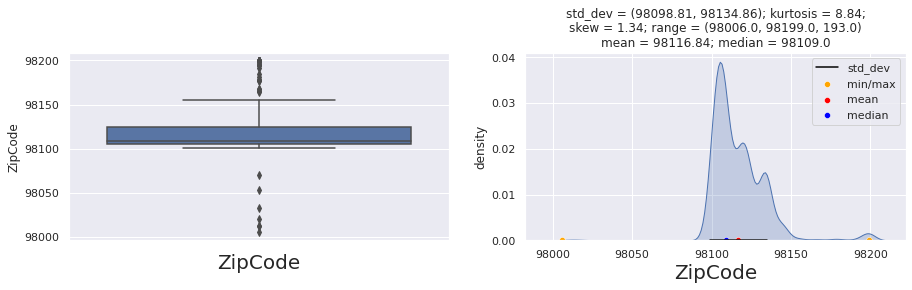

In [223]:
UVA_num_plus(df, ['ZipCode'])

In [224]:
df['ZipCode'].isna().sum()

16

In [225]:
df.loc[df['ZipCode'].isna()]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
3360,Nonresidential COS,Mixed Use Property,NaN,NORTH,2005,1.0,1,20616,0,20616,Shops / Services,Social / Entertainement,Education Facility,NaN,6.369655e+05,4.44
3361,Nonresidential COS,Other,NaN,CENTRAL,2013,1.0,1,11685,0,11685,Public Services,No UseType,No UseType,NaN,8.510538e+05,29.18
3362,Nonresidential COS,Other,NaN,BALLARD,2010,1.0,1,11968,0,11968,Public Services,No UseType,No UseType,NaN,7.834230e+05,23.00
3363,Nonresidential COS,Other,NaN,NORTH,1949,1.0,1,11285,0,11285,Public Services,No UseType,No UseType,NaN,6.456654e+05,14.37
3364,Nonresidential COS,Other,NaN,BALLARD,1911,1.0,1,16795,0,16795,Shops / Services,Social / Entertainement,Education Facility,NaN,9.366165e+05,24.73
3365,Nonresidential COS,Other,NaN,BALLARD,1972,1.0,1,12769,0,12769,Shops / Services,Social / Entertainement,Industry / Offices,NaN,5.117308e+06,216.18
3366,Nonresidential COS,Office,NaN,MAGNOLIA / QUEEN ANNE,1952,1.0,1,13661,0,13661,Industry / Offices,No UseType,No UseType,75.0,5.026677e+05,3.50
3367,Nonresidential COS,Other,NaN,EAST,1912,1.0,1,23445,0,23445,Shops / Services,No UseType,No UseType,NaN,5.976246e+06,259.22
3368,Nonresidential COS,Mixed Use Property,NaN,CENTRAL,1994,1.0,1,20050,0,20050,Shops / Services,Social / Entertainement,Industry / Offices,NaN,1.813404e+06,60.81
3369,Nonresidential COS,Office,NaN,SOUTHEAST,1960,1.0,1,15398,0,15398,Industry / Offices,No UseType,No UseType,93.0,3.878100e+05,7.79


In [226]:
df.shape

(1561, 16)

In [227]:
df = df.loc[~df['ZipCode'].isna()]

In [228]:
df.shape

(1545, 16)

##### ENERGYSTARScore

In [229]:
df['ENERGYSTARScore'].nunique()

100

In [230]:
df['ENERGYSTARScore'].unique()

array([ 60.,  61.,  43.,  56.,  75.,  nan,  27.,  30.,  36.,  48.,  58.,
        35.,  31.,  39.,  76.,  95.,  84.,  57.,  29.,   8.,  97.,  88.,
        83.,  67.,  78.,  14.,  71.,  63.,  98.,  99.,  86.,  80.,  81.,
        94.,  74.,  96.,  37.,  91.,  93.,  68.,  53.,  34., 100.,  89.,
        92.,  90.,  79.,  21.,  10.,  72.,  87.,  70.,  64.,  49.,  62.,
        46.,  42.,  77.,   1.,  20.,  85.,  66.,  69.,  28.,  65.,   3.,
        54.,  45.,   2.,  55.,  25.,   6.,  59.,  19.,   7.,   5.,  23.,
        38.,  73.,  33.,  26.,  41.,  32.,  82.,  15.,  16.,  50.,  51.,
        12.,  13.,  11.,  47.,  18.,  24.,  17.,  52.,  44.,   4.,  40.,
        22.,   9.])

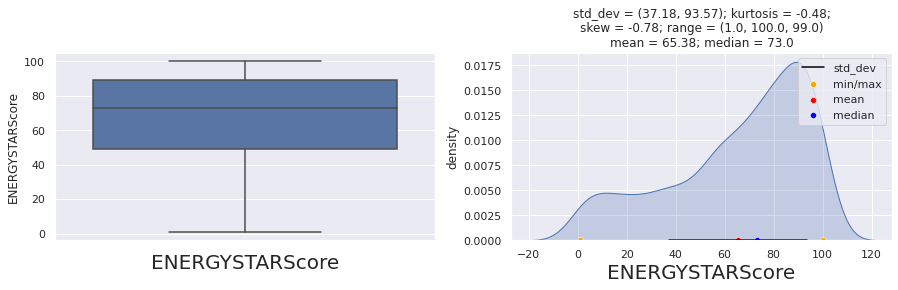

In [231]:
UVA_num_plus(df,['ENERGYSTARScore'])

In [232]:
df.shape

(1545, 16)

In [233]:
df = df.loc[~df['ENERGYSTARScore'].isna()]

In [234]:
df.shape

(1030, 16)

In [235]:
df['ZipCode'].nunique()

40

#### SiteEnergyUseWN(kBtu)

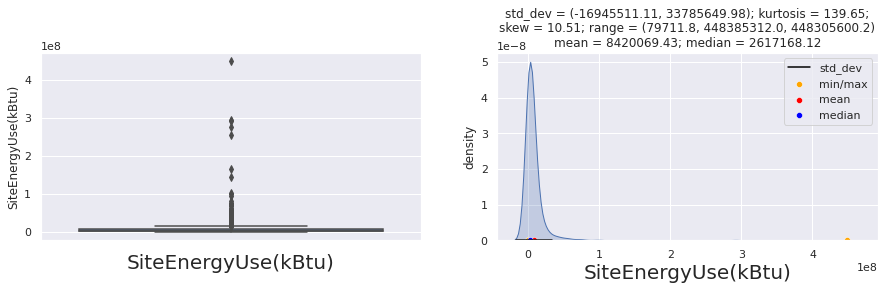

In [236]:
UVA_num_plus(df, ['SiteEnergyUse(kBtu)'])

In [237]:
df['SiteEnergyUse(kBtu)'].isna().sum()

0

In [238]:
df['SiteEnergyUse(kBtu)'].value_counts()

7.226362e+06    1
1.351268e+06    1
8.518313e+06    1
8.587806e+05    1
1.730601e+06    1
               ..
1.475112e+07    1
1.506734e+07    1
8.138616e+06    1
3.065954e+06    1
1.325973e+06    1
Name: SiteEnergyUse(kBtu), Length: 1030, dtype: int64

In [239]:
df.shape

(1030, 16)

In [240]:
df.loc[df['SiteEnergyUse(kBtu)'].isna()]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions


In [241]:
df = df.loc[~df['SiteEnergyUse(kBtu)'].isna()]

In [242]:
df.shape

(1030, 16)

In [243]:
df.loc[df['SiteEnergyUse(kBtu)'] == 0]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions


In [244]:
df.loc[df['SiteEnergyUse(kBtu)'] == 0].any(1).count()

0

In [245]:
df.loc[df['SiteEnergyUse(kBtu)'] > 0].shape

(1030, 16)

In [246]:
df = df.loc[df['SiteEnergyUse(kBtu)'] > 0]

In [247]:
df.shape

(1030, 16)

#### NumberOfBuildings

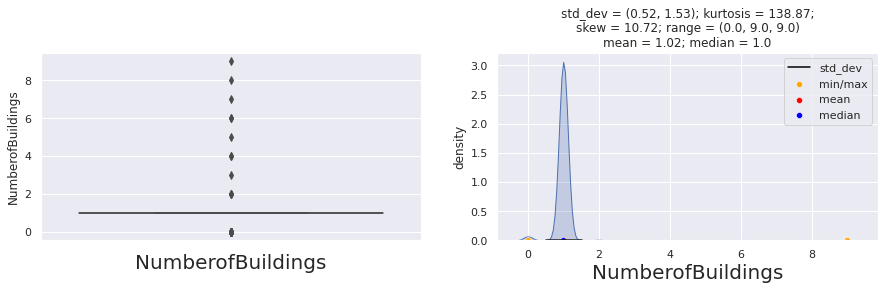

In [248]:
UVA_num_plus(df, ['NumberofBuildings'])

In [249]:
df['NumberofBuildings'].isna().sum()

0

In [250]:
df.loc[df['NumberofBuildings'].isna()]

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions


In [251]:
df['NumberofBuildings'].fillna(1, inplace=True)

In [252]:
df['NumberofBuildings'].value_counts()

1.0    996
0.0     22
2.0      3
4.0      2
6.0      2
9.0      1
7.0      1
5.0      1
3.0      1
8.0      1
Name: NumberofBuildings, dtype: int64

In [253]:
nb_build_outl = df.loc[df['NumberofBuildings'] >= 5]

In [254]:
nb_build_outl.all(1).count()

6

In [255]:
nb_build_outl

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
124,NonResidential,Hospital,98105.0,NORTHEAST,1953,6.0,10,879000,0,879000,health_facilities,No UseType,No UseType,10.0,253832464.0,8145.52
167,NonResidential,Hospital,98122.0,CENTRAL,1990,6.0,5,597519,0,597519,health_facilities,Parking,No UseType,34.0,143423024.0,4906.33
170,NonResidential,Hospital,98104.0,EAST,2000,9.0,8,1158691,0,1158691,health_facilities,Parking,No UseType,29.0,293090784.0,10734.57
618,NonResidential,Hospital,98122.0,EAST,1994,7.0,14,1765970,0,1765970,health_facilities,Parking,No UseType,54.0,291614432.0,12307.16
954,Campus,K-12 School,98115.0,NORTHEAST,1989,5.0,3,21500,0,21500,Education Facility,No UseType,No UseType,44.0,6689184.0,202.65
1672,NonResidential,Hospital,98133.0,NORTHWEST,1966,8.0,1,415632,0,415632,health_facilities,Parking,No UseType,85.0,98960776.0,3278.11


In [256]:
nb_build_outl[['BuildingType', 'PrimaryPropertyType',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'LargestPropertyUseType','SiteEnergyUse(kBtu)', 
       'TotalGHGEmissions']].sort_values(by=['NumberofBuildings'], ascending=False)

,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,LargestPropertyUseType,SiteEnergyUse(kBtu),TotalGHGEmissions
170,NonResidential,Hospital,2000,9.0,8,1158691,health_facilities,293090784.0,10734.57
1672,NonResidential,Hospital,1966,8.0,1,415632,health_facilities,98960776.0,3278.11
618,NonResidential,Hospital,1994,7.0,14,1765970,health_facilities,291614432.0,12307.16
124,NonResidential,Hospital,1953,6.0,10,879000,health_facilities,253832464.0,8145.52
167,NonResidential,Hospital,1990,6.0,5,597519,health_facilities,143423024.0,4906.33
954,Campus,K-12 School,1989,5.0,3,21500,Education Facility,6689184.0,202.65


In [257]:
# replace NumberofBuildings value from 0 to 1
df['NumberofBuildings'].loc[df['NumberofBuildings'] == 0] = 1

In [258]:
df['NumberofBuildings'].value_counts()

1.0    1018
2.0       3
4.0       2
6.0       2
9.0       1
7.0       1
5.0       1
3.0       1
8.0       1
Name: NumberofBuildings, dtype: int64

In [259]:
df.head()

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Shops / Services,No UseType,No UseType,60.0,7226362.5,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Shops / Services,Parking,Shops / Services,61.0,8387933.0,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Shops / Services,No UseType,No UseType,43.0,72587024.0,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Shops / Services,No UseType,No UseType,56.0,6794584.0,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Shops / Services,Parking,Shops / Services,75.0,14172606.0,505.01


## Catégories : simplification

In [260]:
categorical_columns = df.select_dtypes(['category','object']).columns
categorical_columns

Index(['BuildingType', 'PrimaryPropertyType', 'Neighborhood',
       'LargestPropertyUseType', 'SecondLargestPropertyUseType',
       'ThirdLargestPropertyUseType'],
      dtype='object')

In [261]:
print_cats(df, categorical_columns)

--------------------------------------------
--------------------------------------------
Column : BuildingType
----
nunique : 4
['NonResidential' 'SPS-District K-12' 'Campus' 'Nonresidential COS']


--------------------------------------------
--------------------------------------------
Column : PrimaryPropertyType
----
nunique : 14
['Hotel' 'Other' 'K-12 School' 'Mixed Use Property'
 'Small- and Mid-Sized Office' 'Large Office' 'Medical Office'
 'Retail Store' 'Hospital' 'Warehouse' 'Worship Facility'
 'Supermarket / Grocery Store' 'Distribution Center'
 'Refrigerated Warehouse']


--------------------------------------------
--------------------------------------------
Column : Neighborhood
----
nunique : 13
['DOWNTOWN' 'SOUTHEAST' 'NORTHEAST' 'NORTH' 'GREATER DUWAMISH'
 'MAGNOLIA / QUEEN ANNE' 'BALLARD' 'NORTHWEST' 'LAKE UNION' 'EAST'
 'CENTRAL' 'DELRIDGE' 'SOUTHWEST']


--------------------------------------------
--------------------------------------------
Column : LargestPrope

In [262]:
# Simplify most complex / redundant usetypes

In [263]:
df['LargestPropertyUseType'].unique()

array(['Shops / Services', 'Public Services', 'Education Facility',
       'Industry / Offices', 'health_facilities',
       'Social / Entertainement', 'Parking', 'Other', 'No UseType'],
      dtype=object)

In [264]:
df['SecondLargestPropertyUseType'].unique()

array(['No UseType', 'Parking', 'Industry / Offices',
       'Education Facility', 'Shops / Services',
       'Social / Entertainement', 'Other', 'health_facilities'],
      dtype=object)

In [265]:
df['ThirdLargestPropertyUseType'].unique()

array(['No UseType', 'Shops / Services', 'Industry / Offices', 'Other',
       'health_facilities', 'Parking', 'Social / Entertainement',
       'Education Facility', 'Other - Technology/Science'], dtype=object)

# Explore post-cleaning

In [266]:
df.head()

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Shops / Services,No UseType,No UseType,60.0,7226362.5,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Shops / Services,Parking,Shops / Services,61.0,8387933.0,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Shops / Services,No UseType,No UseType,43.0,72587024.0,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Shops / Services,No UseType,No UseType,56.0,6794584.0,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Shops / Services,Parking,Shops / Services,75.0,14172606.0,505.01


In [267]:
df.isna().sum().sum()

0

In [268]:
#show_nulls(df)

## Uni-variée

In [269]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['ZipCode', 'NumberofBuildings', 'ENERGYSTARScore',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions'],
      dtype='object')

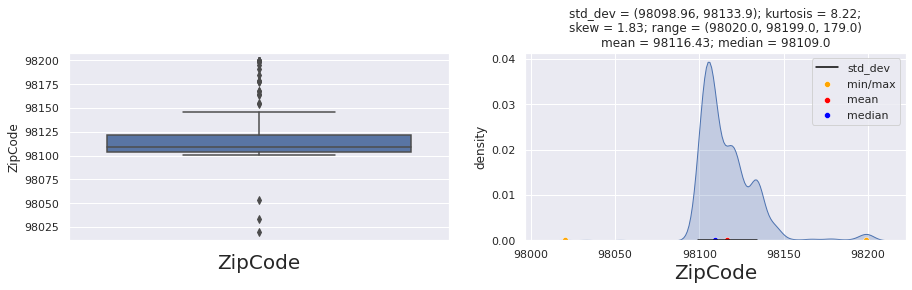

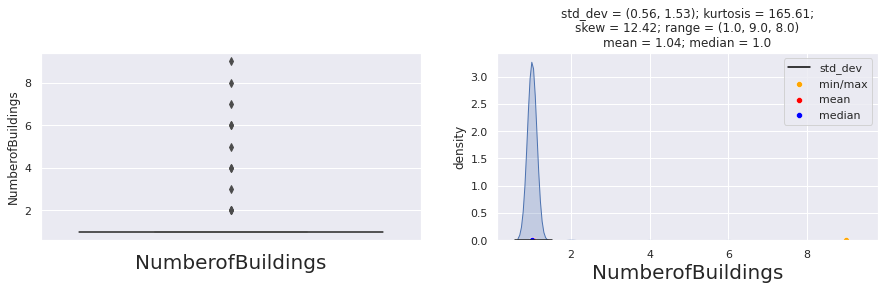

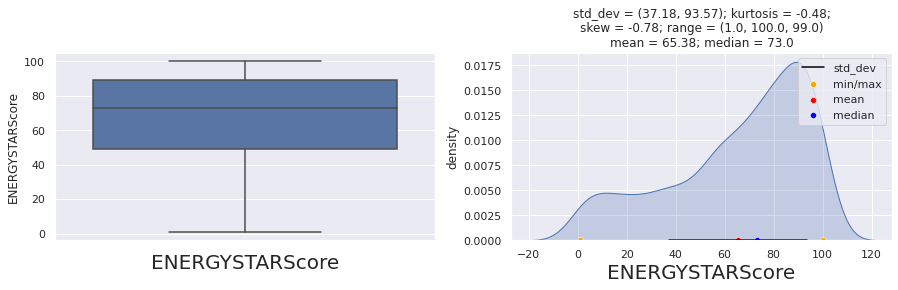

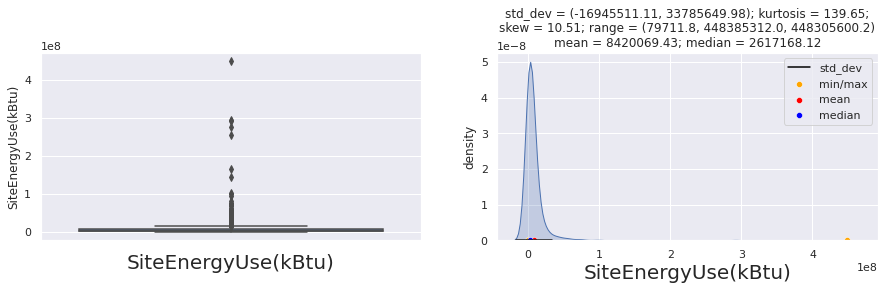

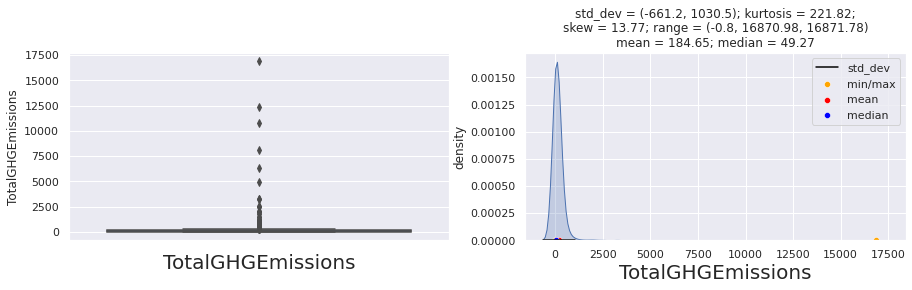

In [270]:
UVA_num_plus(df, num_cols)

In [271]:
num_cols

Index(['ZipCode', 'NumberofBuildings', 'ENERGYSTARScore',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions'],
      dtype='object')

In [272]:
energy_cols = ['SiteEnergyUse(kBtu)']
emission_cols = ['TotalGHGEmissions']

In [273]:
buildings =  ['NumberofBuildings', 'ENERGYSTARScore']

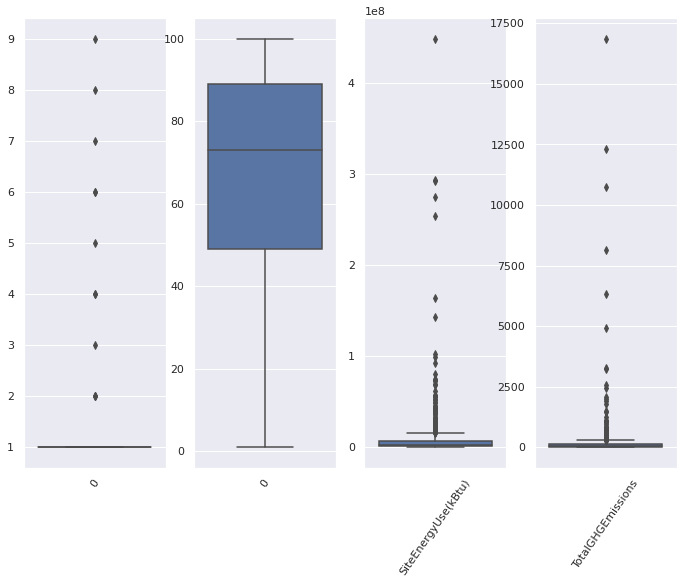

In [274]:
sns.set(rc={'figure.figsize':(11.7,8.27)})

fig, ax  = plt.subplots(1,4, gridspec_kw={'width_ratios': [2, 2, 2, 2]})
sns.boxplot(data=df['NumberofBuildings'], ax=ax[0])
sns.boxplot(data=df['ENERGYSTARScore'], ax=ax[1])
sns.boxplot(data=df[energy_cols], ax=ax[2])
sns.boxplot(data=df[emission_cols], ax=ax[3])
ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=55)
ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=55)
ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=55)
ax[3].set_xticklabels(ax[3].get_xticklabels(),rotation=55)
plt.show()

## Heatmap / matrice corrélation

In [275]:
### années de construction / influence sur autres params ?
## (heatmap de seaborn)

In [276]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['ZipCode', 'NumberofBuildings', 'ENERGYSTARScore',
       'SiteEnergyUse(kBtu)', 'TotalGHGEmissions'],
      dtype='object')

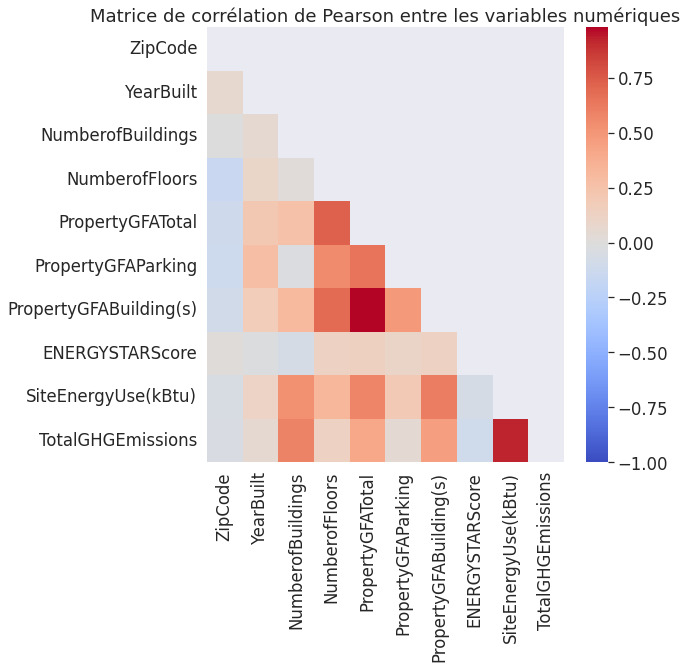

In [277]:
plt.figure(figsize=(8,8))
sns.set(font_scale=1.5)
plt.title('Matrice de corrélation de Pearson entre les variables numériques')


corr = df.corr()
#corr = df[[num_cols]].corr()

#numpy deprecated bool : https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True 

ax = sns.heatmap(corr, mask=mask, vmin=-1, cmap='coolwarm')
plt.show()
sns.set(font_scale=1)

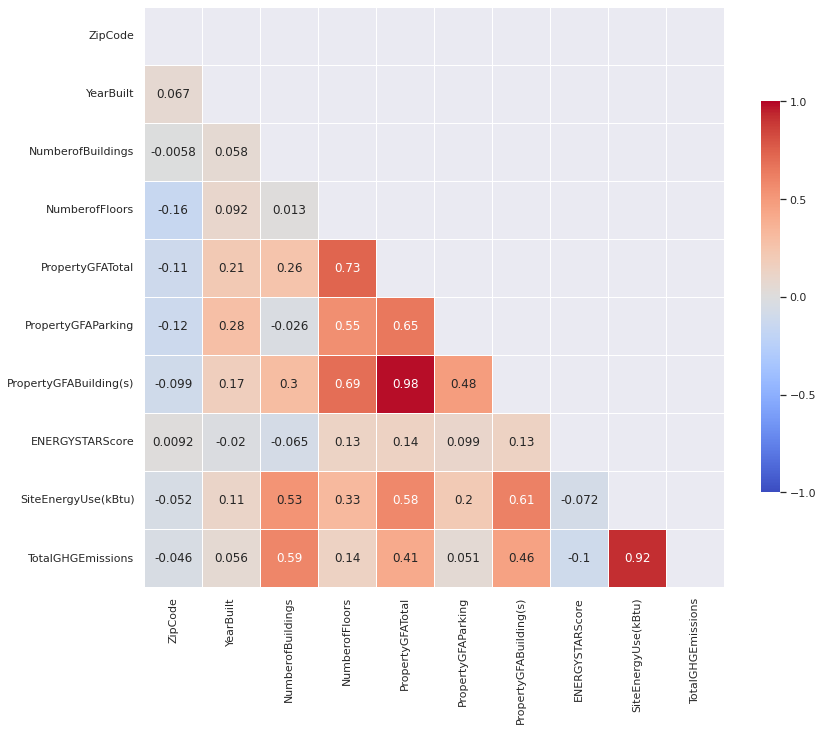

In [278]:
# https://www.kdnuggets.com/2019/07/annotated-heatmaps-correlation-matrix.html
f, ax = plt.subplots(figsize=(13, 18))

corr_matrix = df.corr()

heatmap = sns.heatmap(corr_matrix,
                      mask = mask,
                      square = True,
                      linewidths = .5,
                      cmap = "coolwarm",
                      cbar_kws = {'shrink': .4,
                                "ticks" : [-1, -.5, 0, 0.5, 1]},
                      vmin = -1,
                      vmax = 1,
                      annot = True,
                      annot_kws = {"size": 12})

#add the column names as labels
ax.set_yticklabels(corr_matrix.columns, rotation = 0)
ax.set_xticklabels(corr_matrix.columns)

sns.set_style({'xtick.bottom': True}, {'ytick.left': True})


In [279]:
df.head()

,BuildingType,PrimaryPropertyType,ZipCode,Neighborhood,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions
0,NonResidential,Hotel,98101.0,DOWNTOWN,1927,1.0,12,88434,0,88434,Shops / Services,No UseType,No UseType,60.0,7226362.5,249.98
1,NonResidential,Hotel,98101.0,DOWNTOWN,1996,1.0,11,103566,15064,88502,Shops / Services,Parking,Shops / Services,61.0,8387933.0,295.86
2,NonResidential,Hotel,98101.0,DOWNTOWN,1969,1.0,41,956110,196718,759392,Shops / Services,No UseType,No UseType,43.0,72587024.0,2089.28
3,NonResidential,Hotel,98101.0,DOWNTOWN,1926,1.0,10,61320,0,61320,Shops / Services,No UseType,No UseType,56.0,6794584.0,286.43
4,NonResidential,Hotel,98121.0,DOWNTOWN,1980,1.0,18,175580,62000,113580,Shops / Services,Parking,Shops / Services,75.0,14172606.0,505.01


# Export to CSV

In [280]:
df.reset_index()

df.to_csv(path + 'clean_seattle_buildings.csv', index=False)
print('export finished !')

export finished !


In [281]:
pwd

'/home/mijka/code/openclassrooms/projets/projet_4'

In [282]:
ls -lh ./data

total 1,4M
-rw-r--r-- 1 mijka mijka 1,2M  7 nov.  09:53 2016_Building_Energy_Benchmarking.csv
-rw-r--r-- 1 mijka mijka 143K  7 nov.  15:09 clean_seattle_buildings.csv
